# 02. Cálculo de nSPEI y extracción de eventos de sequía

**Tesis:** *Predicción de sequías mediante modelos de cópulas y datos hidrometeorológicos en la Región Sur del Perú*

## Propósito del cuaderno

Este notebook reproduce la cadena computacional correspondiente al cálculo del **nSPEI en escalas de 3, 6 y 12 meses**, la identificación de eventos de sequía mediante rachas negativas y la generación de tablas y figuras utilizadas en la tesis.

El flujo reproducible implementado es:

1. Lectura y control de la base hidroclimática mensual.
2. Lectura de la clasificación **Ward.D2 definitiva** generada por el notebook 01.
3. Integración de estaciones y clusters.
4. Cálculo del balance hídrico mensual \(P-ETo\).
5. Acumulación móvil a 3, 6 y 12 meses.
6. Cálculo no paramétrico del nSPEI mediante posiciones de probabilidad de **Gringorten**, por estación y mes calendario.
7. Generación de figuras multiescala.
8. Generación del diagrama de Hovmöller del nSPEI-12.
9. Extracción de eventos mediante rachas con nSPEI < 0, reteniendo aquellas que alcanzan \(\min(nSPEI)\le -1\).
10. Cálculo de duración, severidad, intensidad y mínimo del evento.
11. Clasificación de eventos D1--D4.
12. Diagnóstico de suficiencia muestral por estación.
13. Generación de tablas y figuras de resultados.
14. Controles de coherencia con los resultados documentados.
15. Registro de hashes MD5, `sessionInfo()` y manifiesto de productos.

> **Importante:** la clasificación mensual del nSPEI y el criterio de retención de un evento no son lo mismo. Las categorías mensuales comienzan en D0 = \([-0.79,-0.50]\) y D1 = \([-1.29,-0.80]\), mientras que una racha solo ingresa al catálogo de eventos si alcanza al menos \(\min(nSPEI)\le -1.0\).

> **Reproducibilidad:** este notebook consume directamente `03_resultados/01_regionalizacion/tablas/estaciones_clusters.csv`, evitando archivos históricos con sufijos `_ORIGINAL`, `_EXTRAIDO` o `_REPRODUCIDO`.

### Ejecución recomendada

Abra el notebook desde el repositorio `Tesis_UNCP`, reinicie el kernel de R y ejecute **Run All**. Las tablas se mostrarán dentro del cuaderno y se guardarán en:

`03_resultados/02_nspei_eventos/tablas/`

Las figuras se mostrarán en el cuaderno y se guardarán en:

`03_resultados/02_nspei_eventos/figuras/`

Los archivos intermedios y procesados se escribirán en `01_datos/intermedios/` y `01_datos/procesados/`.

## Celda 1. Paquetes, opciones y funciones auxiliares

In [41]:
options(
  stringsAsFactors = FALSE,
  scipen = 999,
  width = 160
)

paquetes_requeridos <- c(
  "dplyr",
  "tidyr",
  "readr",
  "ggplot2",
  "purrr",
  "stringr",
  "lubridate",
  "janitor",
  "zoo",
  "scales",
  "tibble"
)

paquetes_faltantes <- paquetes_requeridos[
  !vapply(
    paquetes_requeridos,
    requireNamespace,
    logical(1),
    quietly = TRUE
  )
]

if (length(paquetes_faltantes) > 0) {
  stop(
    paste0(
      "ERROR: faltan paquetes requeridos: ",
      paste(paquetes_faltantes, collapse = ", "),
      "\n\nRestaure el entorno del proyecto con:\n",
      "renv::restore()\n\n",
      "No se instalan paquetes automáticamente desde este notebook."
    )
  )
}

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(readr)
  library(ggplot2)
  library(purrr)
  library(stringr)
  library(lubridate)
  library(janitor)
  library(zoo)
  library(scales)
  library(tibble)
})

# ----------------------------------------------------------------------
# Mostrar tablas de forma segura dentro de Jupyter.
# Siempre convierte a tibble antes de utilizar n y width.
# ----------------------------------------------------------------------

mostrar_tabla <- function(x, n = Inf) {
  x %>%
    tibble::as_tibble() %>%
    print(
      n = n,
      width = Inf
    )
}

# ----------------------------------------------------------------------
# Guardar una figura en PNG y PDF.
# Si Cairo no está disponible, se usa el dispositivo PDF estándar.
# ----------------------------------------------------------------------

guardar_figura <- function(
  plot,
  nombre_base,
  ruta,
  width,
  height,
  dpi = 600
) {

  archivo_png <- file.path(
    ruta,
    paste0(nombre_base, ".png")
  )

  archivo_pdf <- file.path(
    ruta,
    paste0(nombre_base, ".pdf")
  )

  ggsave(
    filename = archivo_png,
    plot = plot,
    width = width,
    height = height,
    units = "in",
    dpi = dpi,
    bg = "white",
    limitsize = FALSE
  )

  if (capabilities("cairo")) {

    ggsave(
      filename = archivo_pdf,
      plot = plot,
      width = width,
      height = height,
      units = "in",
      device = grDevices::cairo_pdf,
      bg = "white",
      limitsize = FALSE
    )

  } else {

    ggsave(
      filename = archivo_pdf,
      plot = plot,
      width = width,
      height = height,
      units = "in",
      device = "pdf",
      bg = "white",
      limitsize = FALSE
    )
  }

  c(
    png = archivo_png,
    pdf = archivo_pdf
  )
}

cat("Paquetes requeridos: OK\n")

Paquetes requeridos: OK


## Celda 2. Rutas reproducibles del proyecto

In [42]:
# ======================================================================
# LOCALIZAR LA RAÍZ DEL REPOSITORIO
# ======================================================================

encontrar_raiz_proyecto <- function(inicio = getwd()) {

  marcadores <- c(
    "01_datos",
    "02_scripts",
    "03_resultados",
    "04_documentacion"
  )

  es_raiz <- function(x) {
    all(
      dir.exists(
        file.path(
          x,
          marcadores
        )
      )
    )
  }

  raiz_env <- Sys.getenv(
    "TESIS_SEQUIAS_ROOT",
    unset = ""
  )

  if (nzchar(raiz_env)) {

    raiz_env <- normalizePath(
      raiz_env,
      winslash = "/",
      mustWork = FALSE
    )

    if (es_raiz(raiz_env)) {
      return(raiz_env)
    }
  }

  ruta <- normalizePath(
    inicio,
    winslash = "/",
    mustWork = TRUE
  )

  repeat {

    if (es_raiz(ruta)) {
      return(ruta)
    }

    padre <- dirname(ruta)

    if (identical(padre, ruta)) {
      stop(
        "ERROR: no se encontró la raíz del proyecto. ",
        "Ejecute Jupyter desde la raíz del repositorio ",
        "o defina la variable TESIS_SEQUIAS_ROOT."
      )
    }

    ruta <- padre
  }
}

ruta_base <- encontrar_raiz_proyecto()

ruta_raw <- file.path(
  ruta_base,
  "01_datos",
  "raw"
)

ruta_inter <- file.path(
  ruta_base,
  "01_datos",
  "intermedios"
)

ruta_procesados <- file.path(
  ruta_base,
  "01_datos",
  "procesados"
)

ruta_tablas <- file.path(
  ruta_base,
  "03_resultados",
  "02_nspei_eventos",
  "tablas"
)

ruta_figuras <- file.path(
  ruta_base,
  "03_resultados",
  "02_nspei_eventos",
  "figuras"
)

ruta_reproducibilidad <- file.path(
  ruta_base,
  "04_documentacion",
  "reproducibilidad"
)

archivo_base <- file.path(
  ruta_raw,
  "Base_Datos_Final_ETo_Pivot.csv"
)

# IMPORTANTE:
# Se utiliza la salida FINAL del notebook 01.
archivo_cluster <- file.path(
  ruta_base,
  "03_resultados",
  "01_regionalizacion",
  "tablas",
  "estaciones_clusters.csv"
)

directorios <- c(
  ruta_inter,
  ruta_procesados,
  ruta_tablas,
  ruta_figuras,
  ruta_reproducibilidad
)

for (d in directorios) {
  dir.create(
    d,
    recursive = TRUE,
    showWarnings = FALSE
  )
}

if (!file.exists(archivo_base)) {
  stop(
    "ERROR: no se encontró la base hidroclimática:\n",
    archivo_base
  )
}

if (!file.exists(archivo_cluster)) {
  stop(
    "ERROR: no se encontró la clasificación final Ward.D2:\n",
    archivo_cluster,
    "\n\nEjecute primero el notebook 01 de regionalización."
  )
}

cat(
  "\n============================================================\n",
  "RUTAS DEL PROYECTO\n",
  "============================================================\n",
  "Raíz                : ", ruta_base, "\n",
  "Base hidroclimática : ", archivo_base, "\n",
  "Clusters definitivos: ", archivo_cluster, "\n",
  "Tablas              : ", ruta_tablas, "\n",
  "Figuras             : ", ruta_figuras, "\n",
  sep = ""
)


RUTAS DEL PROYECTO
Raíz                : h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB
Base hidroclimática : h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/01_datos/raw/Base_Datos_Final_ETo_Pivot.csv
Clusters definitivos: h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/01_regionalizacion/tablas/estaciones_clusters.csv
Tablas              : h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/02_nspei_eventos/tablas
Figuras             : h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/02_nspei_eventos/figuras


## Celda 3. Lectura y control de la base hidroclimática

In [43]:
# ======================================================================
# LECTURA DE LA BASE ORIGINAL
# ======================================================================

df <- readr::read_csv(
  archivo_base,
  show_col_types = FALSE
) %>%
  janitor::clean_names()

cat("\nColumnas de la base después de clean_names():\n")
print(names(df))

variables_requeridas <- c(
  "fecha",
  "estacion",
  "latitud",
  "longitud",
  "altitud",
  "pt101",
  "e_to_mensual"
)

faltantes <- setdiff(
  variables_requeridas,
  names(df)
)

if (length(faltantes) > 0) {
  stop(
    "ERROR: faltan variables requeridas en la base: ",
    paste(
      faltantes,
      collapse = ", "
    )
  )
}

df <- df %>%
  mutate(
    fecha = as.Date(fecha),
    anio = lubridate::year(fecha),
    mes = lubridate::month(fecha),
    estacion = stringr::str_squish(
      stringr::str_to_upper(estacion)
    )
  ) %>%
  arrange(
    estacion,
    fecha
  )

duplicados <- df %>%
  count(
    estacion,
    fecha,
    name = "n"
  ) %>%
  filter(
    n > 1
  )

if (nrow(duplicados) > 0) {
  mostrar_tabla(duplicados)
  stop(
    "ERROR: existen registros duplicados estación-fecha."
  )
}

n_registros <- nrow(df)
n_estaciones <- n_distinct(df$estacion)
fecha_inicio <- min(df$fecha, na.rm = TRUE)
fecha_fin <- max(df$fecha, na.rm = TRUE)

md5_base <- unname(
  tools::md5sum(
    archivo_base
  )
)

cat(
  "\n============================================================\n",
  "CONTROL DE LA BASE HIDROCLIMÁTICA\n",
  "============================================================\n",
  "Registros mensuales : ", n_registros, "\n",
  "Estaciones          : ", n_estaciones, "\n",
  "Fecha inicial       : ", fecha_inicio, "\n",
  "Fecha final         : ", fecha_fin, "\n",
  "MD5                 : ", md5_base, "\n",
  sep = ""
)

if (n_registros != 18144) {
  warning(
    "ATENCIÓN: se esperaban 18 144 registros y se encontraron ",
    n_registros,
    "."
  )
}

if (n_estaciones != 28) {
  warning(
    "ATENCIÓN: se esperaban 28 estaciones y se encontraron ",
    n_estaciones,
    "."
  )
}


Columnas de la base después de clean_names():
 [1] "fecha"        "estacion"     "latitud"      "longitud"     "altitud"      "hr101"        "pt101"        "tm101"        "vtmed"        "e_to_dia"    
[11] "dias_en_mes"  "e_to_mensual"

CONTROL DE LA BASE HIDROCLIMÁTICA
Registros mensuales : 18144
Estaciones          : 28
Fecha inicial       : 0
Fecha final         : 19692
MD5                 : 7235b7dc7b685f99cfb62ede8d744cf5


## Celda 4. Lectura e integración de la regionalización Ward.D2 definitiva

In [44]:
clusters <- readr::read_csv(
  archivo_cluster,
  show_col_types = FALSE
) %>%
  janitor::clean_names()

variables_cluster_requeridas <- c(
  "estacion",
  "cluster_ward"
)

faltantes_cluster <- setdiff(
  variables_cluster_requeridas,
  names(clusters)
)

if (length(faltantes_cluster) > 0) {
  stop(
    "ERROR: el archivo de regionalización no contiene: ",
    paste(
      faltantes_cluster,
      collapse = ", "
    )
  )
}

clusters <- clusters %>%
  transmute(
    estacion = stringr::str_squish(
      stringr::str_to_upper(estacion)
    ),
    cluster_ward = as.integer(
      as.character(cluster_ward)
    )
  ) %>%
  distinct(
    estacion,
    .keep_all = TRUE
  ) %>%
  arrange(
    estacion
  )

if (nrow(clusters) != 28) {
  warning(
    "ATENCIÓN: el archivo de clusters contiene ",
    nrow(clusters),
    " estaciones y se esperaban 28."
  )
}

md5_cluster <- unname(
  tools::md5sum(
    archivo_cluster
  )
)

df <- df %>%
  left_join(
    clusters,
    by = "estacion"
  )

sin_cluster <- df %>%
  filter(
    is.na(cluster_ward)
  ) %>%
  distinct(
    estacion
  )

if (nrow(sin_cluster) > 0) {
  mostrar_tabla(sin_cluster)
  stop(
    "ERROR: existen estaciones sin asignación Ward.D2."
  )
}

tam_cluster <- df %>%
  distinct(
    estacion,
    cluster_ward
  ) %>%
  count(
    cluster_ward,
    name = "n_estaciones"
  ) %>%
  arrange(
    cluster_ward
  )

cat(
  "\n============================================================\n",
  "REGIONALIZACIÓN IMPORTADA\n",
  "============================================================\n",
  "MD5 archivo clusters: ", md5_cluster, "\n",
  sep = ""
)

mostrar_tabla(
  tam_cluster
)

if (!identical(
  tam_cluster$n_estaciones,
  c(18L, 6L, 4L)
)) {
  warning(
    "ATENCIÓN: los tamaños Ward.D2 actuales no son 18 / 6 / 4."
  )
}

pucara_control <- df %>%
  filter(
    estacion == "PUCARA"
  ) %>%
  distinct(
    estacion,
    altitud,
    cluster_ward
  )

cat("\nControl PUCARA:\n")
mostrar_tabla(pucara_control)


REGIONALIZACIÓN IMPORTADA
MD5 archivo clusters: abe58ea1facc664a8be86c3a91c1b085
# A tibble: 3 × 2
  cluster_ward n_estaciones
         <int>        <int>
1            1           18
2            2            6
3            3            4

Control PUCARA:
# A tibble: 1 × 3
  estacion altitud cluster_ward
  <chr>      <dbl>        <int>
1 PUCARA      3877            1


## Celda 5. Balance hídrico mensual y acumulados móviles

El balance utilizado es:

\[
B_t=P_t-ETo_t
\]

donde \(P_t\) es la precipitación mensual y \(ETo_t\) la evapotranspiración de referencia mensual.

Los acumulados de 3, 6 y 12 meses se calculan mediante ventanas móviles alineadas a la derecha. Si una ventana contiene un valor faltante, el acumulado correspondiente permanece como `NA`.

In [45]:
df_balance <- df %>%
  mutate(
    balance_hidrico = pt101 - e_to_mensual
  )

df_acum <- df_balance %>%
  arrange(
    estacion,
    fecha
  ) %>%
  group_by(
    estacion
  ) %>%
  mutate(
    bh_3 = zoo::rollapplyr(
      balance_hidrico,
      width = 3,
      FUN = sum,
      fill = NA_real_,
      na.rm = FALSE
    ),
    bh_6 = zoo::rollapplyr(
      balance_hidrico,
      width = 6,
      FUN = sum,
      fill = NA_real_,
      na.rm = FALSE
    ),
    bh_12 = zoo::rollapplyr(
      balance_hidrico,
      width = 12,
      FUN = sum,
      fill = NA_real_,
      na.rm = FALSE
    )
  ) %>%
  ungroup()

control_acumulados <- df_acum %>%
  summarise(
    n_balance_validos = sum(is.finite(balance_hidrico)),
    n_bh3_validos = sum(is.finite(bh_3)),
    n_bh6_validos = sum(is.finite(bh_6)),
    n_bh12_validos = sum(is.finite(bh_12))
  )

cat("\nCONTROL DE ACUMULADOS:\n")
mostrar_tabla(control_acumulados)


CONTROL DE ACUMULADOS:
# A tibble: 1 × 4
  n_balance_validos n_bh3_validos n_bh6_validos n_bh12_validos
              <int>         <int>         <int>          <int>
1             18144         18088         18004          17836


## Celda 6. Cálculo no paramétrico del nSPEI

Para cada estación y cada mes calendario se transforman los acumulados \(P-ETo\) mediante posiciones de probabilidad de Gringorten:

$$
p_i=
rac{r_i-0.44}{n+0.12}
$$

donde \(r_i\) es el rango promedio de la observación dentro de su mes calendario y \(n\) el número de observaciones válidas. Posteriormente:

$$
nSPEI_i=\Phi^{-1}(p_i)
$$

La transformación se aplica independientemente en las escalas de 3, 6 y 12 meses.

In [46]:
calc_nspei_np <- function(x) {

  ok <- is.finite(x)

  out <- rep(
    NA_real_,
    length(x)
  )

  n <- sum(ok)

  if (n < 10) {
    return(out)
  }

  ranks <- rank(
    x[ok],
    ties.method = "average"
  )

  p <- (
    ranks - 0.44
  ) / (
    n + 0.12
  )

  p <- pmin(
    pmax(
      p,
      1e-6
    ),
    1 - 1e-6
  )

  out[ok] <- stats::qnorm(
    p
  )

  out
}

df_nspei <- df_acum %>%
  group_by(
    estacion,
    mes
  ) %>%
  mutate(
    nspei_3 = calc_nspei_np(
      bh_3
    ),
    nspei_6 = calc_nspei_np(
      bh_6
    ),
    nspei_12 = calc_nspei_np(
      bh_12
    )
  ) %>%
  ungroup() %>%
  arrange(
    estacion,
    fecha
  )

archivo_base_nspei <- file.path(
  ruta_inter,
  "base_nspei_estaciones.csv"
)

readr::write_csv(
  df_nspei,
  archivo_base_nspei
)

cat(
  "\nBase nSPEI guardada en:\n",
  archivo_base_nspei,
  "\n",
  sep = ""
)


Base nSPEI guardada en:
h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/01_datos/intermedios/base_nspei_estaciones.csv


## Celda 7. Diagnóstico numérico del nSPEI

In [47]:
diagnostico_nspei <- df_nspei %>%
  select(
    estacion,
    fecha,
    nspei_3,
    nspei_6,
    nspei_12
  ) %>%
  pivot_longer(
    cols = starts_with("nspei_"),
    names_to = "escala",
    values_to = "nspei"
  ) %>%
  group_by(
    escala
  ) %>%
  summarise(
    n_validos = sum(is.finite(nspei)),
    n_faltantes = sum(is.na(nspei)),
    media = mean(nspei, na.rm = TRUE),
    desviacion = sd(nspei, na.rm = TRUE),
    minimo = min(nspei, na.rm = TRUE),
    maximo = max(nspei, na.rm = TRUE),
    .groups = "drop"
  )

readr::write_csv(
  diagnostico_nspei,
  file.path(
    ruta_tablas,
    "diagnostico_nspei_por_escala.csv"
  )
)

cat(
  "\n============================================================\n",
  "DIAGNÓSTICO NUMÉRICO DEL nSPEI\n",
  "============================================================\n"
)

mostrar_tabla(
  diagnostico_nspei
)


 DIAGNÓSTICO NUMÉRICO DEL nSPEI
# A tibble: 3 × 7
  escala   n_validos n_faltantes    media desviacion minimo maximo
  <chr>        <int>       <int>    <dbl>      <dbl>  <dbl>  <dbl>
1 nspei_12     17836         308  5.92e-8      0.981  -2.31   2.31
2 nspei_3      18088          56 -1.11e-7      0.981  -2.31   2.31
3 nspei_6      18004         140  1.38e-9      0.981  -2.31   2.31


## Celda 8. Clasificación mensual del nSPEI

La clasificación utilizada para interpretar valores mensuales es:

- D4: \(nSPEI\le -2.00\)
- D3: \(-1.99\le nSPEI\le -1.60\)
- D2: \(-1.59\le nSPEI\le -1.30\)
- D1: \(-1.29\le nSPEI\le -0.80\)
- D0: \(-0.79\le nSPEI\le -0.50\)
- Normal/húmedo: \(nSPEI>-0.50\)

Esta clasificación mensual no debe confundirse con el criterio de retención de rachas, que exige que un evento alcance al menos \(\min(nSPEI)\le -1.0\).

In [48]:
clasificar_nspei_mensual <- function(x) {

  dplyr::case_when(
    is.na(x) ~ NA_character_,
    x <= -2.0 ~ "D4",
    x <= -1.6 ~ "D3",
    x <= -1.3 ~ "D2",
    x <= -0.8 ~ "D1",
    x <= -0.5 ~ "D0",
    TRUE ~ "Normal/húmedo"
  )
}

frecuencia_clases_mensuales <- df_nspei %>%
  select(
    estacion,
    fecha,
    nspei_3,
    nspei_6,
    nspei_12
  ) %>%
  pivot_longer(
    cols = starts_with("nspei_"),
    names_to = "escala",
    values_to = "nspei"
  ) %>%
  mutate(
    clase_mensual = clasificar_nspei_mensual(
      nspei
    ),
    clase_mensual = factor(
      clase_mensual,
      levels = c(
        "D0",
        "D1",
        "D2",
        "D3",
        "D4",
        "Normal/húmedo"
      )
    )
  ) %>%
  count(
    escala,
    clase_mensual,
    name = "n_meses"
  ) %>%
  arrange(
    escala,
    clase_mensual
  )

readr::write_csv(
  frecuencia_clases_mensuales,
  file.path(
    ruta_tablas,
    "frecuencia_clases_mensuales_nspei.csv"
  )
)

cat("\nFRECUENCIA DE CLASES MENSUALES:\n")
mostrar_tabla(frecuencia_clases_mensuales)


FRECUENCIA DE CLASES MENSUALES:
# A tibble: 21 × 3
   escala   clase_mensual n_meses
   <chr>    <fct>           <int>
 1 nspei_12 D0               1708
 2 nspei_12 D1               2016
 3 nspei_12 D2                672
 4 nspei_12 D3                672
 5 nspei_12 D4                336
 6 nspei_12 Normal/húmedo   12432
 7 nspei_12 NA                308
 8 nspei_3  D0               1959
 9 nspei_3  D1               2016
10 nspei_3  D2                672
11 nspei_3  D3                672
12 nspei_3  D4                336
13 nspei_3  Normal/húmedo   12433
14 nspei_3  NA                 56
15 nspei_6  D0               1876
16 nspei_6  D1               2016
17 nspei_6  D2                672
18 nspei_6  D3                672
19 nspei_6  D4                336
20 nspei_6  Normal/húmedo   12432
21 nspei_6  NA                140


## Celda 9. Función para las figuras multiescala por estación

Las figuras muestran nSPEI-3, nSPEI-6 y nSPEI-12 en paneles verticales. Las áreas azules representan valores positivos y las áreas rojizas valores negativos. Las líneas horizontales indican los umbrales mensuales D1, D2, D3 y D4.

Las figuras se guardan en **PNG de alta resolución** y **PDF vectorial**.

In [49]:
graficar_nspei_multiescala <- function(
  df_nspei,
  estacion_obj
) {

  df_plot <- df_nspei %>%
    filter(
      estacion == estacion_obj
    ) %>%
    arrange(
      fecha
    ) %>%
    select(
      fecha,
      estacion,
      nspei_3,
      nspei_6,
      nspei_12
    ) %>%
    pivot_longer(
      cols = c(
        nspei_3,
        nspei_6,
        nspei_12
      ),
      names_to = "escala",
      values_to = "nspei"
    ) %>%
    mutate(
      escala = factor(
        escala,
        levels = c(
          "nspei_3",
          "nspei_6",
          "nspei_12"
        ),
        labels = c(
          "nSPEI-3",
          "nSPEI-6",
          "nSPEI-12"
        )
      ),
      humedo = if_else(
        nspei > 0,
        nspei,
        0
      ),
      seco = if_else(
        nspei < 0,
        nspei,
        0
      )
    )

  if (nrow(df_plot) == 0) {
    stop(
      "No se encontró la estación: ",
      estacion_obj
    )
  }

  umbrales <- tibble::tibble(
    nivel = factor(
      c(
        "D1: -0.8",
        "D2: -1.3",
        "D3: -1.6",
        "D4: -2.0"
      ),
      levels = c(
        "D1: -0.8",
        "D2: -1.3",
        "D3: -1.6",
        "D4: -2.0"
      )
    ),
    y = c(
      -0.8,
      -1.3,
      -1.6,
      -2.0
    )
  )

  limite_y <- max(
    2.5,
    abs(
      df_plot$nspei[
        is.finite(
          df_plot$nspei
        )
      ]
    ),
    na.rm = TRUE
  )

  limite_y <- ceiling(
    limite_y * 2
  ) / 2

  p <- ggplot(
    df_plot,
    aes(
      x = fecha
    )
  ) +

    geom_area(
      aes(
        y = humedo,
        fill = "Superávit / condición húmeda"
      ),
      alpha = 0.82,
      na.rm = TRUE
    ) +

    geom_area(
      aes(
        y = seco,
        fill = "Déficit"
      ),
      alpha = 0.82,
      na.rm = TRUE
    ) +

    geom_line(
      aes(
        y = nspei
      ),
      colour = "grey25",
      linewidth = 0.22,
      alpha = 0.75,
      na.rm = TRUE
    ) +

    geom_hline(
      yintercept = 0,
      colour = "grey20",
      linewidth = 0.55
    ) +

    geom_hline(
      data = umbrales,
      aes(
        yintercept = y,
        linetype = nivel
      ),
      colour = "grey25",
      linewidth = 0.55,
      show.legend = TRUE
    ) +

    facet_grid(
      rows = vars(
        escala
      ),
      switch = "y"
    ) +

    scale_fill_manual(
      name = NULL,
      values = c(
        "Déficit" = "#D95F5F",
        "Superávit / condición húmeda" = "#4C90C0"
      )
    ) +

    scale_linetype_manual(
      name = "Umbrales de sequía",
      values = c(
        "D1: -0.8" = "dashed",
        "D2: -1.3" = "dotdash",
        "D3: -1.6" = "dotted",
        "D4: -2.0" = "longdash"
      )
    ) +

    scale_x_date(
      limits = as.Date(
        c(
          "1970-01-01",
          "2023-12-01"
        )
      ),
      date_breaks = "5 years",
      date_labels = "%Y",
      expand = c(
        0,
        0
      )
    ) +

    coord_cartesian(
      ylim = c(
        -limite_y,
        limite_y
      )
    ) +

    labs(
      x = "Año",
      y = "nSPEI"
    ) +

    guides(
      fill = guide_legend(
        order = 1,
        nrow = 1,
        byrow = TRUE,
        override.aes = list(
          alpha = 1
        )
      ),
      linetype = guide_legend(
        order = 2,
        nrow = 1,
        byrow = TRUE
      )
    ) +

    theme_bw(
      base_size = 11
    ) +

    theme(
      strip.placement = "outside",
      strip.background = element_rect(
        fill = "grey95",
        colour = "grey70",
        linewidth = 0.35
      ),
      strip.text.y.left = element_text(
        angle = 0,
        face = "bold",
        size = 9.5
      ),
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_line(
        colour = "grey88",
        linewidth = 0.30
      ),
      panel.grid.major.y = element_line(
        colour = "grey90",
        linewidth = 0.25
      ),
      axis.title = element_text(
        face = "bold"
      ),
      axis.text.x = element_text(
        angle = 45,
        hjust = 1,
        colour = "black"
      ),
      axis.text.y = element_text(
        colour = "black"
      ),
      legend.position = "bottom",
      legend.box = "vertical",
      legend.title = element_text(
        face = "bold",
        size = 9
      ),
      legend.text = element_text(
        size = 8.5
      ),
      plot.margin = margin(
        8,
        10,
        8,
        10
      )
    )

  p
}

## Celda 10. Mostrar y guardar las figuras multiescala de Ananea y Andahuaylas


FIGURA MULTIESCALA - ANANEA

FIGURA MULTIESCALA - ANDAHUAYLAS


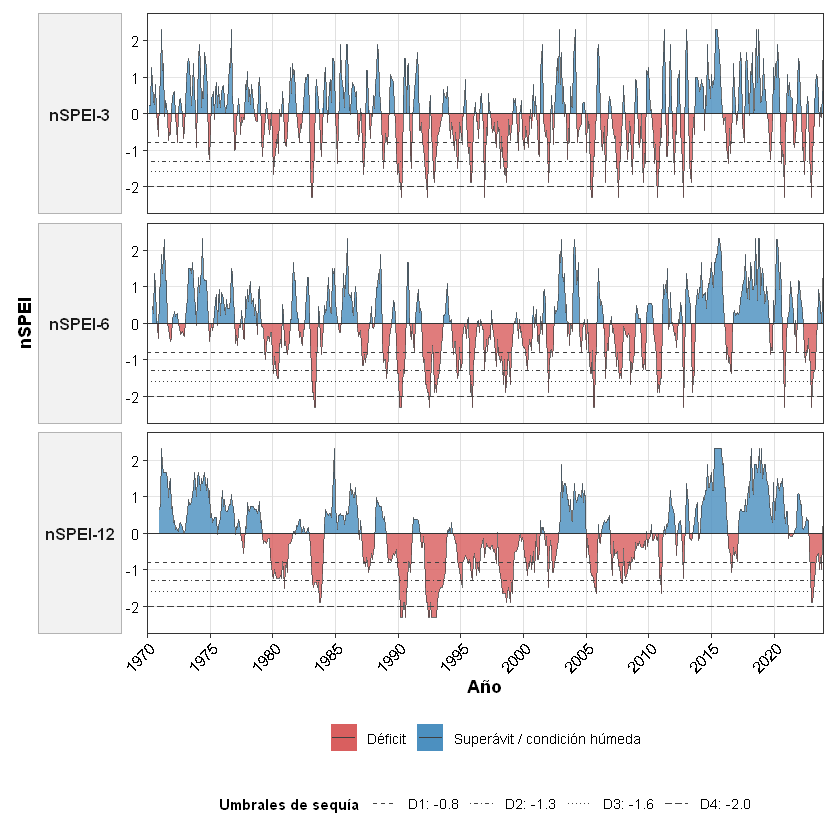

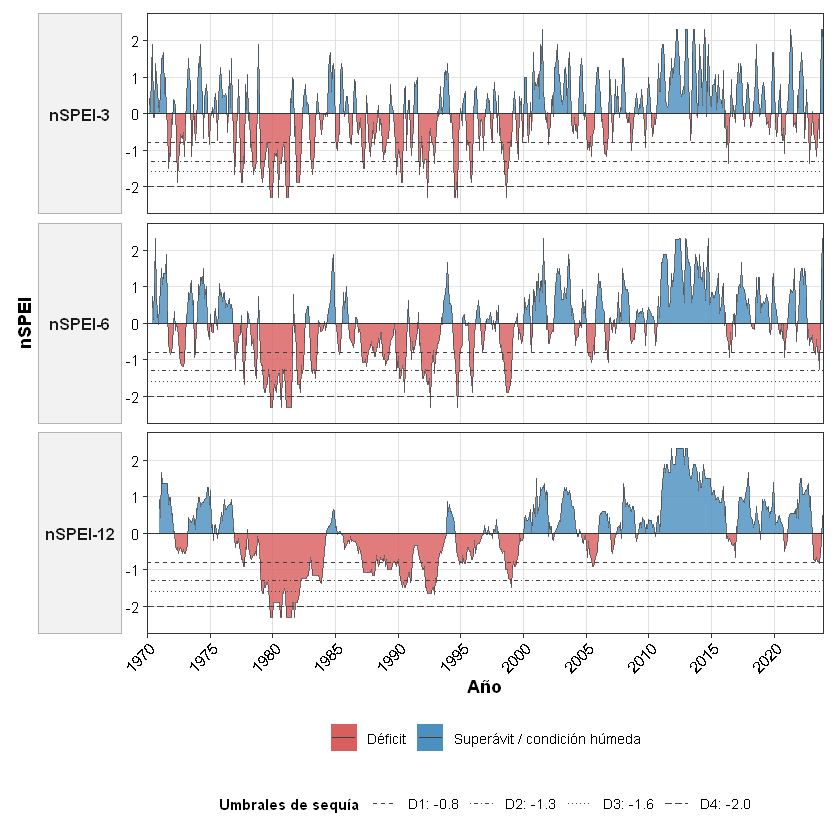

In [50]:
estaciones_muestra <- c(
  "ANANEA",
  "ANDAHUAYLAS"
)

archivos_multiescala_muestra <- character()

for (est in estaciones_muestra) {

  p_est <- graficar_nspei_multiescala(
    df_nspei,
    est
  )

  cat(
    "\nFIGURA MULTIESCALA - ",
    est,
    "\n",
    sep = ""
  )

  print(
    p_est
  )

  nombre_base <- paste0(
    "nspei_multiescala_",
    gsub(
      "[^A-Za-z0-9]+",
      "_",
      est
    )
  )

  rutas_generadas <- guardar_figura(
    plot = p_est,
    nombre_base = nombre_base,
    ruta = ruta_figuras,
    width = 11.0,
    height = 7.8,
    dpi = 600
  )

  archivos_multiescala_muestra <- c(
    archivos_multiescala_muestra,
    rutas_generadas
  )
}

## Celda 11. Guardar las figuras multiescala de las 28 estaciones

Esta celda genera el archivo completo para auditoría y anexos, pero no imprime 28 figuras consecutivas en el notebook. Las figuras de Ananea y Andahuaylas ya se mostraron en la celda anterior.

In [51]:
estaciones <- sort(
  unique(
    df_nspei$estacion
  )
)

archivos_multiescala_todas <- character()

for (est in estaciones) {

  p_est <- graficar_nspei_multiescala(
    df_nspei,
    est
  )

  nombre_base <- paste0(
    "nspei_multiescala_",
    gsub(
      "[^A-Za-z0-9]+",
      "_",
      est
    )
  )

  rutas_generadas <- guardar_figura(
    plot = p_est,
    nombre_base = nombre_base,
    ruta = ruta_figuras,
    width = 11.0,
    height = 7.8,
    dpi = 600
  )

  archivos_multiescala_todas <- c(
    archivos_multiescala_todas,
    rutas_generadas
  )
}

cat(
  "\nFiguras multiescala generadas para ",
  length(estaciones),
  " estaciones.\n",
  sep = ""
)


Figuras multiescala generadas para 28 estaciones.


## Celda 12. Hovmöller del nSPEI-12

Para mejorar la interpretación hidroclimática, las estaciones se ordenan por:

1. cluster Ward.D2;
2. altitud descendente dentro de cada cluster;
3. nombre de estación como criterio secundario.

El tiempo se representa en el eje horizontal y las estaciones en el eje vertical. Los paneles separan los tres clusters. La escala de color es continua: tonos rojizos indican déficit, blanco valores cercanos a cero y tonos azulados condiciones húmedas.


 HOVMÖLLER nSPEI-12 - GENERACIÓN FINAL

Orden hidroclimático de las estaciones:
# A tibble: 28 × 5
   estacion           cluster_ward altitud n_estaciones cluster_label      
   <chr>                     <int>   <dbl>        <int> <fct>              
 1 ANANEA                        1    4660           18 Cluster 1  (n = 18)
 2 IMATA                         1    4475           18 Cluster 1  (n = 18)
 3 MACUSANI                      1    4345           18 Cluster 1  (n = 18)
 4 CAYLLOMA                      1    4327           18 Cluster 1  (n = 18)
 5 PIZACOMA                      1    3930           18 Cluster 1  (n = 18)
 6 MAÑAZO                        1    3910           18 Cluster 1  (n = 18)
 7 HUARAYA MOHO                  1    3890           18 Cluster 1  (n = 18)
 8 PUCARA                        1    3877           18 Cluster 1  (n = 18)
 9 CURPAHUASI                    1    3535           18 Cluster 1  (n = 18)
10 SICUANI                       1    3534           18 Cluster 

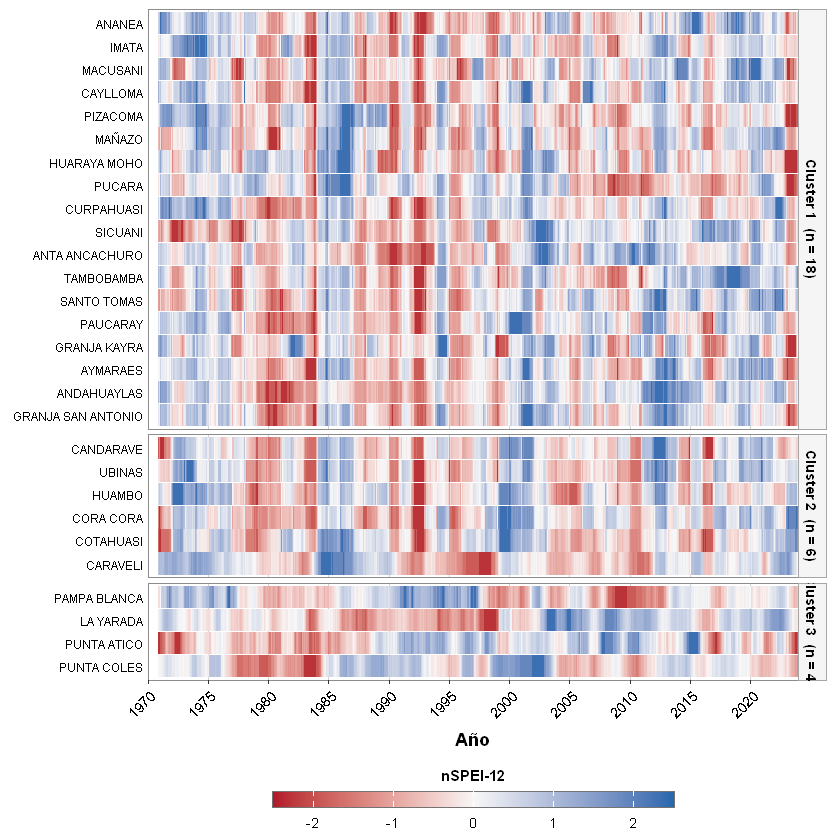

In [52]:
# ======================================================================
# FIGURA HOVMÖLLER nSPEI-12
# VERSIÓN FINAL PARA TESIS
# ======================================================================

cat(
  "\n============================================================\n",
  "HOVMÖLLER nSPEI-12 - GENERACIÓN FINAL\n",
  "============================================================\n"
)


# ======================================================================
# 1. ORDEN HIDROCLIMÁTICO DE LAS ESTACIONES
#
# Se ordenan:
#   1. por cluster Ward.D2;
#   2. por altitud descendente dentro de cada cluster;
#   3. por nombre como criterio secundario.
#
# Esto permite relacionar directamente la figura con la regionalización
# hidroclimática obtenida en el Notebook 01.
# ======================================================================

orden_hov <- df_nspei %>%

  distinct(
    estacion,
    cluster_ward,
    altitud
  ) %>%

  arrange(
    cluster_ward,
    desc(altitud),
    estacion
  )


# ======================================================================
# 2. CALCULAR DINÁMICAMENTE EL TAMAÑO DE CADA CLUSTER
# ======================================================================

tam_hov <- orden_hov %>%

  count(
    cluster_ward,
    name = "n_estaciones"
  )


orden_hov <- orden_hov %>%

  left_join(
    tam_hov,
    by = "cluster_ward"
  ) %>%

  mutate(

    cluster_label = factor(

      paste0(
        "Cluster ",
        cluster_ward,
        "  (n = ",
        n_estaciones,
        ")"
      ),

      levels = paste0(
        "Cluster ",
        tam_hov$cluster_ward,
        "  (n = ",
        tam_hov$n_estaciones,
        ")"
      )
    )
  )


cat(
  "\nOrden hidroclimático de las estaciones:\n"
)

mostrar_tabla(
  orden_hov,
  n = Inf
)


# ======================================================================
# 3. DEFINIR ORDEN DE LAS ESTACIONES EN EL EJE Y
#
# factor() dibuja los niveles desde abajo hacia arriba.
# Se invierte el vector para que la estación de mayor altitud de cada
# cluster aparezca visualmente en la parte superior.
# ======================================================================

niveles_estaciones_hov <- rev(
  orden_hov$estacion
)


# ======================================================================
# 4. CONSTRUIR BASE DEL HOVMÖLLER
# ======================================================================

df_hov12 <- df_nspei %>%

  select(
    fecha,
    estacion,
    cluster_ward,
    altitud,
    nspei_12
  ) %>%

  left_join(

    orden_hov %>%
      select(
        estacion,
        cluster_label
      ),

    by = "estacion"
  ) %>%

  filter(
    fecha >= as.Date("1970-01-01"),
    fecha <= as.Date("2023-12-31")
  ) %>%

  mutate(

    estacion = factor(
      estacion,
      levels = niveles_estaciones_hov
    )
  )


# ======================================================================
# 5. CONTROL DE VALORES NO DISPONIBLES
#
# Los valores NA no se eliminan del archivo de respaldo.
# Se excluyen únicamente de la capa gráfica.
#
# Esto evita mensajes ambiguos de geom_tile() y deja documentado
# exactamente cuántas observaciones no pudieron representarse.
# ======================================================================

diagnostico_na_hov <- df_hov12 %>%

  filter(
    !is.finite(nspei_12)
  ) %>%

  group_by(
    cluster_ward
  ) %>%

  summarise(
    n_no_disponibles = n(),
    primera_fecha = min(
      fecha,
      na.rm = TRUE
    ),
    ultima_fecha = max(
      fecha,
      na.rm = TRUE
    ),
    .groups = "drop"
  )


n_no_disponibles_hov <- sum(
  !is.finite(
    df_hov12$nspei_12
  )
)


cat(
  "\nValores nSPEI-12 no disponibles para representación: ",
  n_no_disponibles_hov,
  "\n",
  sep = ""
)


if (n_no_disponibles_hov > 0) {

  mostrar_tabla(
    diagnostico_na_hov,
    n = Inf
  )
}


# Base utilizada exclusivamente para geom_tile()
df_hov12_plot <- df_hov12 %>%

  filter(
    is.finite(nspei_12)
  )


# ======================================================================
# 6. CONTROL DE INTEGRIDAD
# ======================================================================

if (nrow(df_hov12_plot) == 0) {

  stop(
    "ERROR: no existen valores válidos de nSPEI-12 para construir ",
    "el Hovmöller."
  )
}


if (
  any(
    is.na(
      df_hov12_plot$cluster_label
    )
  )
) {

  stop(
    "ERROR: existen estaciones sin cluster en la base del Hovmöller."
  )
}


cat(
  "Observaciones representadas: ",
  nrow(df_hov12_plot),
  "\n",
  sep = ""
)


# ======================================================================
# 7. CONSTRUIR HOVMÖLLER
# ======================================================================

p_hov12 <- ggplot(

  df_hov12_plot,

  aes(
    x = fecha,
    y = estacion,
    fill = nspei_12
  )

) +

  # --------------------------------------------------------------------
  # Celdas mensuales
  # --------------------------------------------------------------------

  geom_tile(
    width = 31,
    height = 0.96
  ) +

  # --------------------------------------------------------------------
  # Separación por cluster
  #
  # Cada panel conserva una altura proporcional al número de estaciones.
  # --------------------------------------------------------------------

  facet_grid(

    rows = vars(
      cluster_label
    ),

    scales = "free_y",

    space = "free_y"
  ) +

  # --------------------------------------------------------------------
  # Escala divergente centrada en cero
  #
  # Rojo = déficit
  # Blanco = proximidad a cero
  # Azul = condición húmeda
  # --------------------------------------------------------------------

  scale_fill_gradient2(

    low = "#B2182B",

    mid = "#F7F7F7",

    high = "#2166AC",

    midpoint = 0,

    limits = c(
      -2.5,
      2.5
    ),

    oob = scales::squish,

    breaks = c(
      -2,
      -1,
      0,
      1,
      2
    ),

    labels = c(
      "-2",
      "-1",
      "0",
      "1",
      "2"
    ),

    name = "nSPEI-12"
  ) +

  # --------------------------------------------------------------------
  # Eje temporal
  #
  # Marcas principales cada cinco años.
  # --------------------------------------------------------------------

  scale_x_date(

    limits = as.Date(
      c(
        "1970-01-01",
        "2023-12-31"
      )
    ),

    date_breaks = "5 years",

    date_minor_breaks = "1 year",

    date_labels = "%Y",

    expand = c(
      0,
      0
    )
  ) +

  # --------------------------------------------------------------------
  # Etiquetas
  # --------------------------------------------------------------------

  labs(
    x = "Año",
    y = NULL
  ) +

  # --------------------------------------------------------------------
  # Tema editorial
  # --------------------------------------------------------------------

  theme_bw(
    base_size = 11
  ) +

  theme(

    # ------------------------------------------------------------
    # Paneles
    # ------------------------------------------------------------

    panel.background = element_rect(
      fill = "white",
      colour = NA
    ),

    panel.border = element_rect(
      colour = "grey55",
      fill = NA,
      linewidth = 0.35
    ),

    # Líneas verticales principales discretas
    panel.grid.major.x = element_line(
      colour = "grey82",
      linewidth = 0.28
    ),

    panel.grid.minor.x = element_blank(),

    panel.grid.major.y = element_blank(),

    panel.grid.minor.y = element_blank(),


    # ------------------------------------------------------------
    # Etiquetas de clusters
    # Se ubican a la derecha para liberar espacio junto a los
    # nombres de las estaciones.
    # ------------------------------------------------------------

    strip.background = element_rect(
      fill = "grey96",
      colour = "grey65",
      linewidth = 0.35
    ),

    strip.text.y = element_text(
      face = "bold",
      size = 8.3,
      colour = "black"
    ),


    # ------------------------------------------------------------
    # Eje temporal
    # ------------------------------------------------------------

    axis.title.x = element_text(
      face = "bold",
      size = 10.5,
      margin = margin(
        t = 7
      )
    ),

    axis.text.x = element_text(
      angle = 45,
      hjust = 1,
      colour = "black",
      size = 8.3
    ),


    # ------------------------------------------------------------
    # Estaciones
    # ------------------------------------------------------------

    axis.text.y = element_text(
      colour = "black",
      size = 7.4,
      margin = margin(
        r = 3
      )
    ),

    axis.ticks.y = element_blank(),


    # ------------------------------------------------------------
    # Leyenda
    # ------------------------------------------------------------

    legend.position = "bottom",

    legend.direction = "horizontal",

    legend.title = element_text(
      face = "bold",
      size = 9
    ),

    legend.text = element_text(
      size = 8.5
    ),

    legend.margin = margin(
      t = 0,
      r = 0,
      b = 0,
      l = 0
    ),

    # ------------------------------------------------------------
    # Separación entre clusters
    # ------------------------------------------------------------

    panel.spacing.y = grid::unit(
      0.12,
      "cm"
    ),


    # ------------------------------------------------------------
    # Márgenes
    # ------------------------------------------------------------

    plot.margin = margin(
      t = 6,
      r = 8,
      b = 6,
      l = 4
    )
  ) +

  # --------------------------------------------------------------------
  # Barra continua horizontal
  # --------------------------------------------------------------------

  guides(

    fill = guide_colourbar(

      title.position = "top",

      title.hjust = 0.5,

      barwidth = grid::unit(
        8.5,
        "cm"
      ),

      barheight = grid::unit(
        0.35,
        "cm"
      ),

      ticks = TRUE,

      frame.colour = "grey45"
    )
  )


# ======================================================================
# 8. MOSTRAR FIGURA EN EL NOTEBOOK
# ======================================================================

print(
  p_hov12
)


# ======================================================================
# 9. RUTAS DE SALIDA
# ======================================================================

archivo_hov_png <- file.path(
  ruta_figuras,
  "Hovmoller_nSPEI_12.png"
)


archivo_hov_pdf <- file.path(
  ruta_figuras,
  "Hovmoller_nSPEI_12.pdf"
)


# ======================================================================
# 10. GUARDAR PNG DE ALTA RESOLUCIÓN
# ======================================================================

ggsave(

  filename = archivo_hov_png,

  plot = p_hov12,

  width = 11.8,

  height = 10.2,

  units = "in",

  dpi = 600,

  bg = "white",

  limitsize = FALSE
)


# ======================================================================
# 11. GUARDAR PDF VECTORIAL
#
# Se utiliza el dispositivo PDF estándar de R en lugar de cairo_pdf.
# Esto evita el error:
#
#   cairo error 'error while writing to output stream'
#
# useDingbats = FALSE mejora además la compatibilidad con LaTeX.
# ======================================================================

pdf_guardado <- tryCatch(

  {

    grDevices::pdf(

      file = archivo_hov_pdf,

      width = 11.8,

      height = 10.2,

      onefile = TRUE,

      useDingbats = FALSE,

      bg = "white"
    )


    print(
      p_hov12
    )


    grDevices::dev.off()


    TRUE
  },

  error = function(e) {

    # Cerrar dispositivo si quedó abierto
    try(
      grDevices::dev.off(),
      silent = TRUE
    )


    warning(
      "No fue posible generar el PDF: ",
      conditionMessage(e),
      "\nEl PNG sí fue generado correctamente."
    )


    FALSE
  }
)


# ======================================================================
# 12. GUARDAR DATOS COMPLETOS DE RESPALDO
#
# IMPORTANTE:
# Se exporta df_hov12, no df_hov12_plot.
# De esta manera los NA permanecen documentados en el producto numérico.
# ======================================================================

archivo_hov_csv <- file.path(
  ruta_tablas,
  "fig_hovmoller_nspei12_datos.csv"
)


readr::write_csv(

  df_hov12 %>%

    mutate(
      estacion = as.character(
        estacion
      )
    ),

  archivo_hov_csv
)


# ======================================================================
# 13. GUARDAR ORDEN DE ESTACIONES
# ======================================================================

archivo_orden_hov <- file.path(
  ruta_tablas,
  "fig_hovmoller_nspei12_orden_estaciones.csv"
)


readr::write_csv(
  orden_hov,
  archivo_orden_hov
)


# ======================================================================
# 14. RESULTADO FINAL
# ======================================================================

cat(
  "\n============================================================\n",
  "HOVMÖLLER nSPEI-12 GENERADO CORRECTAMENTE\n",
  "============================================================\n"
)


cat(
  "Estaciones                : ",
  n_distinct(
    df_hov12$estacion
  ),
  "\n",
  sep = ""
)


cat(
  "Observaciones totales     : ",
  nrow(
    df_hov12
  ),
  "\n",
  sep = ""
)


cat(
  "Observaciones graficadas  : ",
  nrow(
    df_hov12_plot
  ),
  "\n",
  sep = ""
)


cat(
  "Valores no disponibles    : ",
  n_no_disponibles_hov,
  "\n",
  sep = ""
)


cat(
  "Orden                     : cluster Ward.D2 + altitud descendente\n"
)


cat(
  "PNG                       : ",
  archivo_hov_png,
  "\n",
  sep = ""
)


cat(
  "PDF                       : ",
  ifelse(
    pdf_guardado,
    archivo_hov_pdf,
    "NO GENERADO"
  ),
  "\n",
  sep = ""
)


cat(
  "CSV                       : ",
  archivo_hov_csv,
  "\n",
  sep = ""
)


cat(
  "CSV orden estaciones      : ",
  archivo_orden_hov,
  "\n",
  sep = ""
)


cat(
  "============================================================\n"
)

## Celda 13. Identificación de eventos de sequía

Un evento se define en dos etapas:

1. Se identifica una **racha consecutiva con nSPEI < 0**.
2. La racha se conserva únicamente si alcanza al menos \(\min(nSPEI)\le -1.0\).

Para cada evento:

$$
D = 	ext{número de meses de la racha}
$$

$$
S=-\sum_{t=1}^{D}nSPEI_t
$$

$$
I=
rac{S}{D}
$$

La duración y la severidad se calculan sobre **toda la racha negativa**, no solo sobre los meses inferiores a \(-1\).

In [53]:
# ======================================================================
# CELDA 13. IDENTIFICACIÓN DE EVENTOS DE SEQUÍA
# MEDIANTE RACHAS NEGATIVAS DEL nSPEI
# ======================================================================

cat(
  "\n============================================================\n",
  "IDENTIFICACIÓN DE EVENTOS DE SEQUÍA\n",
  "============================================================\n"
)


# ======================================================================
# 1. FUNCIÓN PARA EXTRAER EVENTOS DE UNA ESTACIÓN Y UNA ESCALA
# ======================================================================
#
# DEFINICIÓN UTILIZADA:
#
# 1. Una racha comienza y continúa mientras:
#
#       nSPEI < 0
#
# 2. La racha se conserva como evento de sequía únicamente si:
#
#       min(nSPEI) <= -1
#
# 3. La duración corresponde al número completo de meses consecutivos
#    con nSPEI < 0.
#
# 4. La severidad se calcula sobre TODA la racha negativa:
#
#       S = -sum(nSPEI)
#
# 5. La intensidad media del evento es:
#
#       I = S / D
#
# IMPORTANTE:
# El umbral -1 NO delimita la duración.
# Solo determina si la racha negativa se conserva como evento.
# ======================================================================


extraer_eventos <- function(
  df_est,
  var_nspei,
  umbral_inicio = 0,
  umbral_sequia = -1
) {

  # --------------------------------------------------------------------
  # Orden cronológico obligatorio
  # --------------------------------------------------------------------

  df_est <- df_est %>%
    arrange(fecha)


  # --------------------------------------------------------------------
  # Verificar que la variable nSPEI exista
  # --------------------------------------------------------------------

  if (!var_nspei %in% names(df_est)) {

    stop(
      "ERROR: la variable ",
      var_nspei,
      " no existe en la base."
    )
  }


  # --------------------------------------------------------------------
  # Extraer serie nSPEI y fechas
  # --------------------------------------------------------------------

  x <- df_est[[var_nspei]]

  fechas <- df_est$fecha


  # --------------------------------------------------------------------
  # Identificar meses pertenecientes a una racha negativa
  # --------------------------------------------------------------------

  en_evento <- !is.na(x) &
    x < umbral_inicio


  # --------------------------------------------------------------------
  # Codificar secuencias consecutivas mediante rle()
  # --------------------------------------------------------------------

  r <- rle(
    en_evento
  )


  fin <- cumsum(
    r$lengths
  )


  ini <- fin -
    r$lengths +
    1


  # --------------------------------------------------------------------
  # Tabla vacía donde se almacenarán los eventos
  # --------------------------------------------------------------------

  eventos <- tibble::tibble()


  # --------------------------------------------------------------------
  # Revisar cada racha consecutiva
  # --------------------------------------------------------------------

  for (i in seq_along(r$values)) {

    if (isTRUE(r$values[i])) {

      idx <- ini[i]:fin[i]

      vals <- x[idx]


      # ----------------------------------------------------------------
      # Mínimo nSPEI alcanzado durante toda la racha
      # ----------------------------------------------------------------

      minimo_evento <- min(
        vals,
        na.rm = TRUE
      )


      # ----------------------------------------------------------------
      # La racha entra al catálogo solo si alcanza nSPEI <= -1
      # ----------------------------------------------------------------

      if (
        minimo_evento <=
        umbral_sequia
      ) {

        # --------------------------------------------------------------
        # Duración total de la racha negativa
        # --------------------------------------------------------------

        duracion_evento <- length(
          idx
        )


        # --------------------------------------------------------------
        # Severidad acumulada sobre TODA la racha
        # --------------------------------------------------------------

        severidad_evento <- sum(
          -vals,
          na.rm = TRUE
        )


        # --------------------------------------------------------------
        # Intensidad media
        # --------------------------------------------------------------

        intensidad_evento <-
          severidad_evento /
          duracion_evento


        # --------------------------------------------------------------
        # Incorporar evento al catálogo
        # --------------------------------------------------------------

        eventos <- dplyr::bind_rows(

          eventos,

          tibble::tibble(

            estacion =
              dplyr::first(
                df_est$estacion
              ),

            cluster_ward =
              dplyr::first(
                df_est$cluster_ward
              ),

            escala =
              var_nspei,

            fecha_inicio =
              min(
                fechas[idx]
              ),

            fecha_fin =
              max(
                fechas[idx]
              ),

            duracion =
              duracion_evento,

            severidad =
              severidad_evento,

            intensidad =
              intensidad_evento,

            minimo_nspei =
              minimo_evento
          )
        )
      }
    }
  }


  return(
    eventos
  )
}


# ======================================================================
# 2. FUNCIÓN PARA PROCESAR TODAS LAS ESTACIONES DE UNA ESCALA
# ======================================================================

extraer_eventos_escala <- function(
  df_base,
  variable
) {

  df_base %>%

    group_by(
      estacion
    ) %>%

    group_split() %>%

    purrr::map_dfr(

      ~ extraer_eventos(

        df_est = .x,

        var_nspei = variable,

        umbral_inicio = 0,

        umbral_sequia = -1
      )
    )
}


# ======================================================================
# 3. EXTRAER EVENTOS nSPEI-3
# ======================================================================

eventos_3 <- extraer_eventos_escala(
  df_base = df_nspei,
  variable = "nspei_3"
)


# ======================================================================
# 4. EXTRAER EVENTOS nSPEI-6
# ======================================================================

eventos_6 <- extraer_eventos_escala(
  df_base = df_nspei,
  variable = "nspei_6"
)


# ======================================================================
# 5. EXTRAER EVENTOS nSPEI-12
# ======================================================================

eventos_12 <- extraer_eventos_escala(
  df_base = df_nspei,
  variable = "nspei_12"
)


# ======================================================================
# 6. INTEGRAR LAS TRES ESCALAS
# ======================================================================

eventos_all <- bind_rows(
  eventos_3,
  eventos_6,
  eventos_12
) %>%
  arrange(
    escala,
    cluster_ward,
    estacion,
    fecha_inicio
  )


# ======================================================================
# 7. CONTROL DE INTEGRIDAD
# ======================================================================

if (nrow(eventos_all) == 0) {

  stop(
    "ERROR: no se identificó ningún evento de sequía."
  )
}


if (
  any(
    eventos_all$duracion <= 0
  )
) {

  stop(
    "ERROR: existen eventos con duración <= 0."
  )
}


if (
  any(
    eventos_all$severidad <= 0
  )
) {

  stop(
    "ERROR: existen eventos con severidad <= 0."
  )
}


if (
  any(
    eventos_all$minimo_nspei > -1
  )
) {

  stop(
    "ERROR: existen eventos retenidos cuyo mínimo nSPEI es mayor que -1."
  )
}


if (
  any(
    eventos_all$fecha_fin <
      eventos_all$fecha_inicio
  )
) {

  stop(
    "ERROR: existen eventos con fecha final anterior a la inicial."
  )
}


cat(
  "Control de integridad de eventos: OK\n"
)


# ======================================================================
# 8. RESUMEN DE EVENTOS POR ESCALA
# ======================================================================

resumen_eventos_escala <- eventos_all %>%

  count(
    escala,
    name = "n_eventos"
  ) %>%

  arrange(
    match(
      escala,
      c(
        "nspei_3",
        "nspei_6",
        "nspei_12"
      )
    )
  )


cat(
  "\n============================================================\n",
  "NÚMERO TOTAL DE EVENTOS POR ESCALA\n",
  "============================================================\n"
)


print(
  resumen_eventos_escala,
  n = Inf,
  width = Inf
)


# ======================================================================
# 9. RESUMEN DE EVENTOS POR CLUSTER Y ESCALA
# ======================================================================

resumen_eventos_cluster <- eventos_all %>%

  count(
    escala,
    cluster_ward,
    name = "n_eventos"
  ) %>%

  arrange(
    match(
      escala,
      c(
        "nspei_3",
        "nspei_6",
        "nspei_12"
      )
    ),
    cluster_ward
  )


cat(
  "\n============================================================\n",
  "EVENTOS POR CLUSTER Y ESCALA\n",
  "============================================================\n"
)


print(
  resumen_eventos_cluster,
  n = Inf,
  width = Inf
)


# ======================================================================
# 10. MOSTRAR LOS PRIMEROS 20 EVENTOS
# ======================================================================

cat(
  "\n============================================================\n",
  "PRIMEROS 20 EVENTOS IDENTIFICADOS\n",
  "============================================================\n"
)


eventos_all %>%

  slice_head(
    n = 20
  ) %>%

  tibble::as_tibble() %>%

  print(
    n = 20,
    width = Inf
  )


# ======================================================================
# 11. GUARDAR CATÁLOGO COMPLETO
# ======================================================================

archivo_eventos <- file.path(
  ruta_procesados,
  "eventos_nspei_todas_escalas.csv"
)


readr::write_csv(
  eventos_all,
  archivo_eventos
)


# ======================================================================
# 12. GUARDAR RESÚMENES PARA TRAZABILIDAD
# ======================================================================

readr::write_csv(

  resumen_eventos_escala,

  file.path(
    ruta_tablas,
    "conteo_total_eventos_por_escala.csv"
  )
)


readr::write_csv(

  resumen_eventos_cluster,

  file.path(
    ruta_tablas,
    "conteo_eventos_por_cluster_y_escala_preclasificacion.csv"
  )
)


# ======================================================================
# 13. RESULTADO FINAL DE LA CELDA
# ======================================================================

cat(
  "\n============================================================\n",
  "EXTRACCIÓN DE EVENTOS COMPLETADA\n",
  "============================================================\n"
)


cat(
  "Eventos nSPEI-3  : ",
  nrow(eventos_3),
  "\n",
  sep = ""
)


cat(
  "Eventos nSPEI-6  : ",
  nrow(eventos_6),
  "\n",
  sep = ""
)


cat(
  "Eventos nSPEI-12 : ",
  nrow(eventos_12),
  "\n",
  sep = ""
)


cat(
  "Eventos totales  : ",
  nrow(eventos_all),
  "\n",
  sep = ""
)


cat(
  "\nArchivo generado:\n",
  archivo_eventos,
  "\n",
  sep = ""
)


cat(
  "============================================================\n"
)


 IDENTIFICACIÓN DE EVENTOS DE SEQUÍA
Control de integridad de eventos: OK

 NÚMERO TOTAL DE EVENTOS POR ESCALA
# A tibble: 3 × 2
  escala   n_eventos
  <chr>        <int>
1 nspei_3        797
2 nspei_6        507
3 nspei_12       252

 EVENTOS POR CLUSTER Y ESCALA
# A tibble: 9 × 3
  escala   cluster_ward n_eventos
  <chr>           <int>     <int>
1 nspei_3             1       584
2 nspei_3             2       152
3 nspei_3             3        61
4 nspei_6             1       377
5 nspei_6             2        97
6 nspei_6             3        33
7 nspei_12            1       188
8 nspei_12            2        49
9 nspei_12            3        15

 PRIMEROS 20 EVENTOS IDENTIFICADOS
# A tibble: 20 × 9
   estacion       cluster_ward escala   fecha_inicio fecha_fin  duracion severidad intensidad minimo_nspei
   <chr>                 <int> <chr>    <date>       <date>        <int>     <dbl>      <dbl>        <dbl>
 1 ANANEA                    1 nspei_12 1979-03-01   1981-08-01       30 

## Celda 14. Resumen de eventos por estación, cluster y escala

In [54]:
conteo_estacion <- eventos_all %>%
  group_by(
    estacion,
    cluster_ward,
    escala
  ) %>%
  summarise(
    n_eventos = n(),
    duracion_media = mean(
      duracion,
      na.rm = TRUE
    ),
    duracion_mediana = median(
      duracion,
      na.rm = TRUE
    ),
    severidad_media = mean(
      severidad,
      na.rm = TRUE
    ),
    severidad_mediana = median(
      severidad,
      na.rm = TRUE
    ),
    intensidad_media = mean(
      intensidad,
      na.rm = TRUE
    ),
    minimo_medio = mean(
      minimo_nspei,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  arrange(
    escala,
    cluster_ward,
    desc(n_eventos)
  )

conteo_cluster <- eventos_all %>%
  group_by(
    cluster_ward,
    escala
  ) %>%
  summarise(
    n_eventos = n(),
    duracion_media = mean(
      duracion,
      na.rm = TRUE
    ),
    duracion_mediana = median(
      duracion,
      na.rm = TRUE
    ),
    severidad_media = mean(
      severidad,
      na.rm = TRUE
    ),
    severidad_mediana = median(
      severidad,
      na.rm = TRUE
    ),
    intensidad_media = mean(
      intensidad,
      na.rm = TRUE
    ),
    minimo_medio = mean(
      minimo_nspei,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  arrange(
    escala,
    cluster_ward
  )

resumen_escala <- eventos_all %>%
  group_by(
    escala
  ) %>%
  summarise(
    n_eventos = n(),
    duracion_media = mean(
      duracion,
      na.rm = TRUE
    ),
    duracion_mediana = median(
      duracion,
      na.rm = TRUE
    ),
    severidad_media = mean(
      severidad,
      na.rm = TRUE
    ),
    severidad_mediana = median(
      severidad,
      na.rm = TRUE
    ),
    intensidad_media = mean(
      intensidad,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  arrange(
    escala
  )

readr::write_csv(
  conteo_estacion,
  file.path(
    ruta_tablas,
    "conteo_eventos_por_estacion_y_escala.csv"
  )
)

readr::write_csv(
  conteo_cluster,
  file.path(
    ruta_tablas,
    "conteo_eventos_por_cluster_y_escala.csv"
  )
)

readr::write_csv(
  resumen_escala,
  file.path(
    ruta_tablas,
    "resumen_eventos_por_escala.csv"
  )
)

cat(
  "\n============================================================\n",
  "EVENTOS POR CLUSTER Y ESCALA\n",
  "============================================================\n"
)

mostrar_tabla(
  conteo_cluster
)

cat("\nRESUMEN POR ESCALA:\n")
mostrar_tabla(
  resumen_escala
)


 EVENTOS POR CLUSTER Y ESCALA
# A tibble: 9 × 9
  cluster_ward escala   n_eventos duracion_media duracion_mediana severidad_media severidad_mediana intensidad_media minimo_medio
         <int> <chr>        <int>          <dbl>            <dbl>           <dbl>             <dbl>            <dbl>        <dbl>
1            1 nspei_12       188          22.8                17           21.7              17.2             0.918        -1.68
2            2 nspei_12        49          29.9                24           28.0              23.7             0.947        -1.74
3            3 nspei_12        15          59.7                48           58.8              38.5             0.950        -1.82
4            1 nspei_3        584           6.90                6            6.70              5.15            0.943        -1.61
5            2 nspei_3        152           9.03                7            8.73              5.87            0.918        -1.60
6            3 nspei_3         61        

## Celda 15. Diagnóstico de suficiencia muestral

La suficiencia descriptiva utilizada para evaluar el número de eventos disponibles por estación es:

- **Muy insuficiente:** \(n<10\)
- **Insuficiente:** \(10\le n\le14\)
- **Limitado:** \(15\le n\le19\)
- **Aceptable:** \(20\le n\le29\)
- **Bueno:** \(n\ge30\)

Estas categorías son un diagnóstico de tamaño muestral y no constituyen una prueba estadística formal.

In [55]:
estaciones_pocos_eventos <- conteo_estacion %>%
  mutate(
    criterio_copula = case_when(
      n_eventos < 10 ~ "Muy insuficiente",
      n_eventos < 15 ~ "Insuficiente",
      n_eventos < 20 ~ "Limitado",
      n_eventos < 30 ~ "Aceptable",
      TRUE ~ "Bueno"
    ),
    criterio_copula = factor(
      criterio_copula,
      levels = c(
        "Muy insuficiente",
        "Insuficiente",
        "Limitado",
        "Aceptable",
        "Bueno"
      ),
      ordered = TRUE
    )
  ) %>%
  arrange(
    escala,
    n_eventos
  )

resumen_suficiencia <- estaciones_pocos_eventos %>%
  count(
    escala,
    criterio_copula,
    name = "n_estaciones",
    .drop = FALSE
  ) %>%
  group_by(
    escala
  ) %>%
  mutate(
    porcentaje = 100 *
      n_estaciones /
      sum(n_estaciones)
  ) %>%
  ungroup()

suficiencia_adecuada <- estaciones_pocos_eventos %>%
  group_by(
    escala
  ) %>%
  summarise(
    n_estaciones = n(),
    n_aceptable_bueno = sum(
      n_eventos >= 20
    ),
    porcentaje_aceptable_bueno = 100 *
      n_aceptable_bueno /
      n_estaciones,
    .groups = "drop"
  )

readr::write_csv(
  estaciones_pocos_eventos,
  file.path(
    ruta_tablas,
    "diagnostico_suficiencia_eventos_por_estacion.csv"
  )
)

readr::write_csv(
  resumen_suficiencia,
  file.path(
    ruta_tablas,
    "resumen_suficiencia_eventos_por_escala.csv"
  )
)

readr::write_csv(
  suficiencia_adecuada,
  file.path(
    ruta_tablas,
    "resumen_suficiencia_aceptable_bueno.csv"
  )
)

cat("\nDIAGNÓSTICO DE SUFICIENCIA POR CATEGORÍA:\n")
mostrar_tabla(
  resumen_suficiencia
)

cat("\nESTACIONES CON n >= 20 EVENTOS:\n")
mostrar_tabla(
  suficiencia_adecuada
)

suf_nspei3 <- suficiencia_adecuada %>%
  filter(
    escala == "nspei_3"
  )

if (
  nrow(suf_nspei3) == 1 &&
  (
    suf_nspei3$n_aceptable_bueno != 24 ||
    abs(
      suf_nspei3$porcentaje_aceptable_bueno -
      85.7142857
    ) > 0.1
  )
) {
  warning(
    "ATENCIÓN: nSPEI-3 no reproduce 24/28 estaciones ",
    "con suficiencia Aceptable/Bueno."
  )
}


DIAGNÓSTICO DE SUFICIENCIA POR CATEGORÍA:
# A tibble: 15 × 4
   escala   criterio_copula  n_estaciones porcentaje
   <chr>    <ord>                   <int>      <dbl>
 1 nspei_12 Muy insuficiente           15      53.6 
 2 nspei_12 Insuficiente               10      35.7 
 3 nspei_12 Limitado                    3      10.7 
 4 nspei_12 Aceptable                   0       0   
 5 nspei_12 Bueno                       0       0   
 6 nspei_3  Muy insuficiente            0       0   
 7 nspei_3  Insuficiente                2       7.14
 8 nspei_3  Limitado                    2       7.14
 9 nspei_3  Aceptable                  11      39.3 
10 nspei_3  Bueno                      13      46.4 
11 nspei_6  Muy insuficiente            4      14.3 
12 nspei_6  Insuficiente                1       3.57
13 nspei_6  Limitado                   11      39.3 
14 nspei_6  Aceptable                  12      42.9 
15 nspei_6  Bueno                       0       0   

ESTACIONES CON n >= 20 EVENTOS:
# A 

## Celda 16. Clasificación de eventos de sequía D1--D4

La clase de cada **evento retenido** se asigna según el mínimo nSPEI alcanzado durante la racha:

- D1: \(-1.29 \le \min(nSPEI) \le -1.00\)
- D2: \(-1.59 \le \min(nSPEI) \le -1.30\)
- D3: \(-1.99 \le \min(nSPEI) \le -1.60\)
- D4: \(\min(nSPEI)\le -2.00\)

La categoría D0 no aparece en el catálogo de eventos porque una racha solo se retiene si alcanza \(\min(nSPEI)\le -1.0\).

In [56]:
eventos_clasificados <- eventos_all %>%
  mutate(
    clase_evento = case_when(
      minimo_nspei <= -2.0 ~ "D4 - Excepcional",
      minimo_nspei <= -1.6 ~ "D3 - Extrema",
      minimo_nspei <= -1.3 ~ "D2 - Severa",
      minimo_nspei <= -1.0 ~ "D1 - Moderada",
      TRUE ~ "No clasificada"
    ),
    clase_evento = factor(
      clase_evento,
      levels = c(
        "D1 - Moderada",
        "D2 - Severa",
        "D3 - Extrema",
        "D4 - Excepcional",
        "No clasificada"
      )
    )
  )

frecuencia_clases <- eventos_clasificados %>%
  count(
    escala,
    clase_evento,
    name = "n_eventos",
    .drop = FALSE
  ) %>%
  arrange(
    escala,
    clase_evento
  )

archivo_eventos_clasificados <- file.path(
  ruta_procesados,
  "eventos_nspei_todas_escalas_clasificados.csv"
)

readr::write_csv(
  eventos_clasificados,
  archivo_eventos_clasificados
)

readr::write_csv(
  frecuencia_clases,
  file.path(
    ruta_tablas,
    "frecuencia_clases_eventos_por_escala.csv"
  )
)

cat(
  "\n============================================================\n",
  "FRECUENCIA DE CLASES DE EVENTOS\n",
  "============================================================\n"
)

mostrar_tabla(
  frecuencia_clases
)


 FRECUENCIA DE CLASES DE EVENTOS
# A tibble: 15 × 3
   escala   clase_evento     n_eventos
   <chr>    <fct>                <int>
 1 nspei_12 D1 - Moderada           70
 2 nspei_12 D2 - Severa             50
 3 nspei_12 D3 - Extrema            62
 4 nspei_12 D4 - Excepcional        70
 5 nspei_12 No clasificada           0
 6 nspei_3  D1 - Moderada          273
 7 nspei_3  D2 - Severa            154
 8 nspei_3  D3 - Extrema           207
 9 nspei_3  D4 - Excepcional       163
10 nspei_3  No clasificada           0
11 nspei_6  D1 - Moderada          136
12 nspei_6  D2 - Severa            114
13 nspei_6  D3 - Extrema           135
14 nspei_6  D4 - Excepcional       122
15 nspei_6  No clasificada           0


## Celda 17. Controles de coherencia con los resultados definitivos documentados

In [57]:
# ======================================================================
# CONTROLES: NO MODIFICAN RESULTADOS
# Solo advierten si una nueva ejecución difiere de los valores esperados.
# ======================================================================

esperado_cluster <- tribble(
  ~escala,    ~cluster_ward, ~n_eventos,
  "nspei_3",   1L,            584L,
  "nspei_3",   2L,            152L,
  "nspei_3",   3L,             61L,
  "nspei_6",   1L,            377L,
  "nspei_6",   2L,             97L,
  "nspei_6",   3L,             33L,
  "nspei_12",  1L,            188L,
  "nspei_12",  2L,             49L,
  "nspei_12",  3L,             15L
)

observado_cluster <- conteo_cluster %>%
  select(
    escala,
    cluster_ward,
    n_eventos
  ) %>%
  mutate(
    cluster_ward = as.integer(
      cluster_ward
    )
  ) %>%
  arrange(
    escala,
    cluster_ward
  )

comparacion_cluster <- full_join(
  esperado_cluster,
  observado_cluster,
  by = c(
    "escala",
    "cluster_ward"
  ),
  suffix = c(
    "_esperado",
    "_observado"
  )
) %>%
  mutate(
    coincide = n_eventos_esperado ==
      n_eventos_observado
  )

cat("\nCONTROL DE EVENTOS POR CLUSTER Y ESCALA:\n")
mostrar_tabla(
  comparacion_cluster
)

if (
  any(
    !comparacion_cluster$coincide,
    na.rm = TRUE
  ) ||
  anyNA(
    comparacion_cluster$coincide
  )
) {
  warning(
    "ATENCIÓN: los conteos de eventos por cluster/escala ",
    "difieren de los resultados documentados."
  )
}

esperado_clases <- tribble(
  ~escala,    ~clase_evento,        ~n_eventos,
  "nspei_3",  "D1 - Moderada",       273L,
  "nspei_3",  "D2 - Severa",         154L,
  "nspei_3",  "D3 - Extrema",        207L,
  "nspei_3",  "D4 - Excepcional",    163L,
  "nspei_6",  "D1 - Moderada",       136L,
  "nspei_6",  "D2 - Severa",         114L,
  "nspei_6",  "D3 - Extrema",        135L,
  "nspei_6",  "D4 - Excepcional",    122L,
  "nspei_12", "D1 - Moderada",        70L,
  "nspei_12", "D2 - Severa",          50L,
  "nspei_12", "D3 - Extrema",         62L,
  "nspei_12", "D4 - Excepcional",     70L
)

observado_clases <- frecuencia_clases %>%
  filter(
    clase_evento != "No clasificada"
  ) %>%
  mutate(
    clase_evento = as.character(
      clase_evento
    )
  ) %>%
  select(
    escala,
    clase_evento,
    n_eventos
  )

comparacion_clases <- full_join(
  esperado_clases,
  observado_clases,
  by = c(
    "escala",
    "clase_evento"
  ),
  suffix = c(
    "_esperado",
    "_observado"
  )
) %>%
  mutate(
    coincide = n_eventos_esperado ==
      n_eventos_observado
  )

cat("\nCONTROL DE CLASES DE EVENTOS:\n")
mostrar_tabla(
  comparacion_clases
)

if (
  any(
    !comparacion_clases$coincide,
    na.rm = TRUE
  ) ||
  anyNA(
    comparacion_clases$coincide
  )
) {
  warning(
    "ATENCIÓN: las clases de eventos difieren de los ",
    "resultados documentados."
  )
}


CONTROL DE EVENTOS POR CLUSTER Y ESCALA:
# A tibble: 9 × 5
  escala   cluster_ward n_eventos_esperado n_eventos_observado coincide
  <chr>           <int>              <int>               <int> <lgl>   
1 nspei_3             1                584                 584 TRUE    
2 nspei_3             2                152                 152 TRUE    
3 nspei_3             3                 61                  61 TRUE    
4 nspei_6             1                377                 377 TRUE    
5 nspei_6             2                 97                  97 TRUE    
6 nspei_6             3                 33                  33 TRUE    
7 nspei_12            1                188                 188 TRUE    
8 nspei_12            2                 49                  49 TRUE    
9 nspei_12            3                 15                  15 TRUE    

CONTROL DE CLASES DE EVENTOS:
# A tibble: 12 × 5
   escala   clase_evento     n_eventos_esperado n_eventos_observado coincide
   <chr>    <chr>    

## Celda 18. Figura — número de eventos por cluster y escala

Esta figura resume la reducción del número de eventos al aumentar la escala temporal y permite comparar directamente los tres clusters.

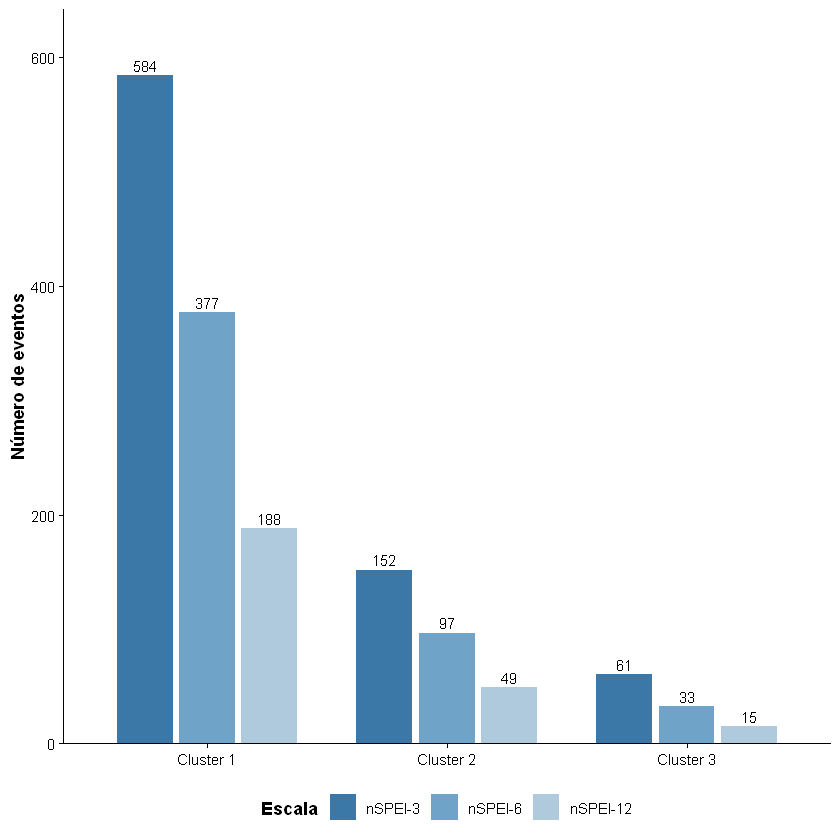

In [58]:
datos_fig_cluster <- conteo_cluster %>%
  mutate(
    cluster = factor(
      paste0(
        "Cluster ",
        cluster_ward
      ),
      levels = c(
        "Cluster 1",
        "Cluster 2",
        "Cluster 3"
      )
    ),
    escala_label = factor(
      escala,
      levels = c(
        "nspei_3",
        "nspei_6",
        "nspei_12"
      ),
      labels = c(
        "nSPEI-3",
        "nSPEI-6",
        "nSPEI-12"
      )
    )
  )

p_cluster <- ggplot(
  datos_fig_cluster,
  aes(
    x = cluster,
    y = n_eventos,
    fill = escala_label
  )
) +

  geom_col(
    position = position_dodge(
      width = 0.78
    ),
    width = 0.70
  ) +

  geom_text(
    aes(
      label = n_eventos
    ),
    position = position_dodge(
      width = 0.78
    ),
    vjust = -0.35,
    size = 3.2
  ) +

  scale_fill_manual(
    values = c(
      "nSPEI-3" = "#3B78A8",
      "nSPEI-6" = "#6FA4C8",
      "nSPEI-12" = "#AFC9DD"
    ),
    name = "Escala"
  ) +

  scale_y_continuous(
    expand = expansion(
      mult = c(
        0,
        0.10
      )
    )
  ) +

  labs(
    x = NULL,
    y = "Número de eventos"
  ) +

  theme_classic(
    base_size = 11
  ) +

  theme(
    axis.title.y = element_text(
      face = "bold"
    ),
    axis.text = element_text(
      colour = "black"
    ),
    legend.position = "bottom",
    legend.title = element_text(
      face = "bold"
    )
  )

print(
  p_cluster
)

archivos_fig_cluster <- guardar_figura(
  plot = p_cluster,
  nombre_base = "numero_eventos_por_cluster_y_escala",
  ruta = ruta_figuras,
  width = 7.5,
  height = 5.2,
  dpi = 600
)

## Celda 19. Figura — distribución de clases de eventos por escala

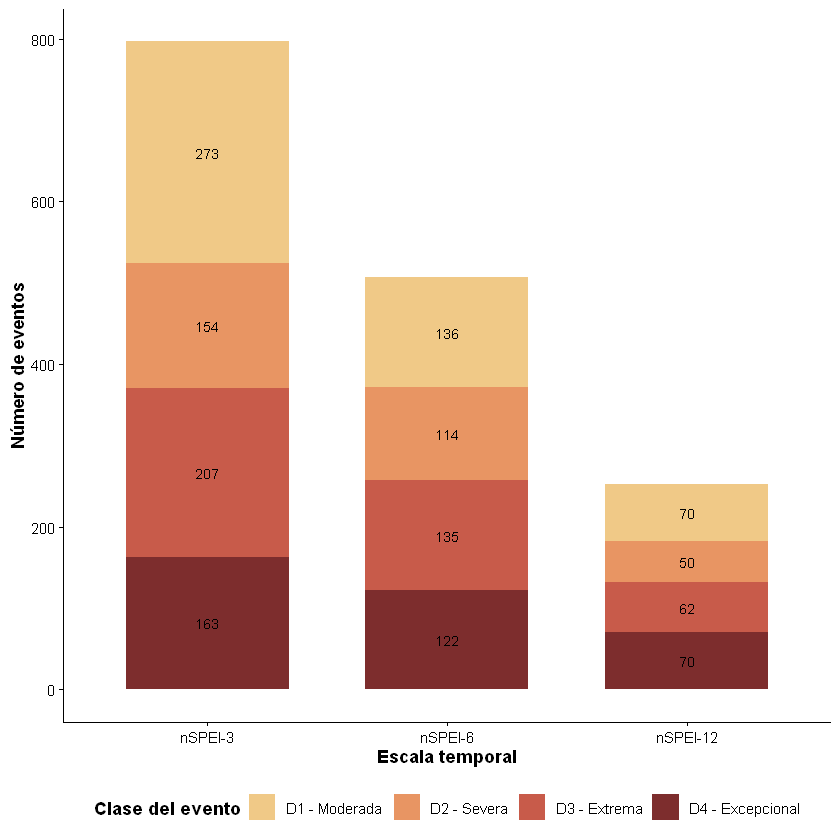

In [59]:
datos_fig_clases <- frecuencia_clases %>%
  filter(
    clase_evento != "No clasificada"
  ) %>%
  mutate(
    clase_evento = droplevels(
      clase_evento
    ),
    escala_label = factor(
      escala,
      levels = c(
        "nspei_3",
        "nspei_6",
        "nspei_12"
      ),
      labels = c(
        "nSPEI-3",
        "nSPEI-6",
        "nSPEI-12"
      )
    )
  )

p_clases <- ggplot(
  datos_fig_clases,
  aes(
    x = escala_label,
    y = n_eventos,
    fill = clase_evento
  )
) +

  geom_col(
    width = 0.68
  ) +

  geom_text(
    aes(
      label = ifelse(
        n_eventos > 0,
        n_eventos,
        ""
      )
    ),
    position = position_stack(
      vjust = 0.5
    ),
    size = 3.0
  ) +

  scale_fill_manual(
    values = c(
      "D1 - Moderada" = "#F0C987",
      "D2 - Severa" = "#E89563",
      "D3 - Extrema" = "#C85B4A",
      "D4 - Excepcional" = "#7D2D2D"
    ),
    drop = FALSE,
    name = "Clase del evento"
  ) +

  labs(
    x = "Escala temporal",
    y = "Número de eventos"
  ) +

  theme_classic(
    base_size = 11
  ) +

  theme(
    axis.title = element_text(
      face = "bold"
    ),
    axis.text = element_text(
      colour = "black"
    ),
    legend.position = "bottom",
    legend.title = element_text(
      face = "bold"
    )
  )

print(
  p_clases
)

archivos_fig_clases <- guardar_figura(
  plot = p_clases,
  nombre_base = "clases_eventos_por_escala",
  ruta = ruta_figuras,
  width = 7.5,
  height = 5.3,
  dpi = 600
)

## Celda 20. Figura — número de eventos por estación y escala

Esta figura está diseñada principalmente para anexos y auditoría, porque muestra las 28 estaciones individualmente.

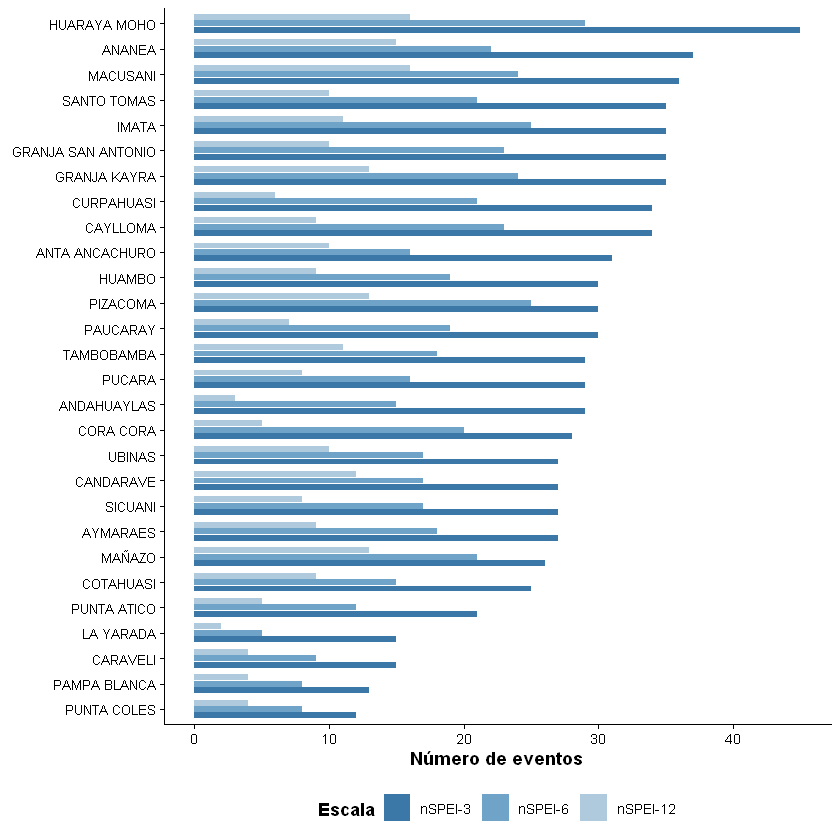

In [60]:
datos_fig_estacion <- conteo_estacion %>%
  mutate(
    escala_label = factor(
      escala,
      levels = c(
        "nspei_3",
        "nspei_6",
        "nspei_12"
      ),
      labels = c(
        "nSPEI-3",
        "nSPEI-6",
        "nSPEI-12"
      )
    )
  )

orden_estaciones_eventos <- datos_fig_estacion %>%
  filter(
    escala == "nspei_3"
  ) %>%
  arrange(
    n_eventos
  ) %>%
  pull(
    estacion
  )

datos_fig_estacion <- datos_fig_estacion %>%
  mutate(
    estacion = factor(
      estacion,
      levels = orden_estaciones_eventos
    )
  )

p_estacion <- ggplot(
  datos_fig_estacion,
  aes(
    x = estacion,
    y = n_eventos,
    fill = escala_label
  )
) +

  geom_col(
    position = position_dodge(
      width = 0.76
    ),
    width = 0.70
  ) +

  coord_flip() +

  scale_fill_manual(
    values = c(
      "nSPEI-3" = "#3B78A8",
      "nSPEI-6" = "#6FA4C8",
      "nSPEI-12" = "#AFC9DD"
    ),
    name = "Escala"
  ) +

  labs(
    x = NULL,
    y = "Número de eventos"
  ) +

  theme_classic(
    base_size = 10.5
  ) +

  theme(
    axis.title.x = element_text(
      face = "bold"
    ),
    axis.text = element_text(
      colour = "black"
    ),
    axis.text.y = element_text(
      size = 8
    ),
    legend.position = "bottom",
    legend.title = element_text(
      face = "bold"
    )
  )

print(
  p_estacion
)

archivos_fig_estacion <- guardar_figura(
  plot = p_estacion,
  nombre_base = "numero_eventos_por_estacion_y_escala",
  ruta = ruta_figuras,
  width = 9.2,
  height = 8.5,
  dpi = 600
)

## Celda 21. Tabla consolidada de resultados para tesis y anexos

In [61]:
tabla_resultados_eventos <- conteo_cluster %>%
  mutate(
    escala_label = factor(
      escala,
      levels = c(
        "nspei_3",
        "nspei_6",
        "nspei_12"
      ),
      labels = c(
        "nSPEI-3",
        "nSPEI-6",
        "nSPEI-12"
      )
    )
  ) %>%
  select(
    escala_label,
    cluster_ward,
    n_eventos,
    duracion_media,
    duracion_mediana,
    severidad_media,
    severidad_mediana,
    intensidad_media,
    minimo_medio
  ) %>%
  arrange(
    escala_label,
    cluster_ward
  )

readr::write_csv(
  tabla_resultados_eventos,
  file.path(
    ruta_tablas,
    "tabla_resumen_eventos_cluster_escala.csv"
  )
)

cat("\nTABLA CONSOLIDADA DE EVENTOS POR CLUSTER Y ESCALA:\n")
mostrar_tabla(
  tabla_resultados_eventos
)


TABLA CONSOLIDADA DE EVENTOS POR CLUSTER Y ESCALA:


# A tibble: 9 × 9
  escala_label cluster_ward n_eventos duracion_media duracion_mediana severidad_media severidad_mediana intensidad_media minimo_medio
  <fct>               <int>     <int>          <dbl>            <dbl>           <dbl>             <dbl>            <dbl>        <dbl>
1 nSPEI-3                 1       584           6.90                6            6.70              5.15            0.943        -1.61
2 nSPEI-3                 2       152           9.03                7            8.73              5.87            0.918        -1.60
3 nSPEI-3                 3        61          16.4                13           15.3               9.72            0.880        -1.65
4 nSPEI-6                 1       377          11.1                10           10.6               8.38            0.925        -1.66
5 nSPEI-6                 2        97          13.9                11           13.6              11.0             0.952        -1.65
6 nSPEI-6                 3        33       

## Celda 22. Diagnóstico global de la ejecución

In [62]:
totales_eventos <- eventos_clasificados %>%
  count(
    escala,
    name = "n_eventos"
  ) %>%
  arrange(
    escala
  )

total_3 <- totales_eventos %>%
  filter(
    escala == "nspei_3"
  ) %>%
  pull(
    n_eventos
  )

total_6 <- totales_eventos %>%
  filter(
    escala == "nspei_6"
  ) %>%
  pull(
    n_eventos
  )

total_12 <- totales_eventos %>%
  filter(
    escala == "nspei_12"
  ) %>%
  pull(
    n_eventos
  )

diagnostico_global <- tibble::tibble(
  indicador = c(
    "archivo_base",
    "md5_base",
    "archivo_cluster",
    "md5_cluster",
    "n_registros",
    "n_estaciones",
    "fecha_inicio",
    "fecha_fin",
    "metodo_balance",
    "acumulaciones_meses",
    "estandarizacion",
    "posicion_probabilidad",
    "agrupacion_estandarizacion",
    "umbral_inicio_racha",
    "umbral_retencion_evento",
    "definicion_severidad",
    "eventos_nspei3",
    "eventos_nspei6",
    "eventos_nspei12",
    "tamano_cluster_1",
    "tamano_cluster_2",
    "tamano_cluster_3",
    "altitud_pucara",
    "suficiencia_nspei3_n_ge_20",
    "suficiencia_nspei3_porcentaje"
  ),
  valor = c(
    basename(
      archivo_base
    ),
    md5_base,
    basename(
      archivo_cluster
    ),
    md5_cluster,
    as.character(
      n_registros
    ),
    as.character(
      n_estaciones
    ),
    as.character(
      fecha_inicio
    ),
    as.character(
      fecha_fin
    ),
    "P - ETo",
    "3 / 6 / 12",
    "No paramétrica",
    "(r - 0.44) / (n + 0.12)",
    "Estación + mes calendario",
    "nSPEI < 0",
    "min(nSPEI) <= -1",
    "-sum(nSPEI) sobre toda la racha negativa",
    as.character(
      total_3
    ),
    as.character(
      total_6
    ),
    as.character(
      total_12
    ),
    as.character(
      tam_cluster$n_estaciones[
        tam_cluster$cluster_ward == 1
      ]
    ),
    as.character(
      tam_cluster$n_estaciones[
        tam_cluster$cluster_ward == 2
      ]
    ),
    as.character(
      tam_cluster$n_estaciones[
        tam_cluster$cluster_ward == 3
      ]
    ),
    as.character(
      pucara_control$altitud[
        1
      ]
    ),
    as.character(
      suf_nspei3$n_aceptable_bueno[
        1
      ]
    ),
    as.character(
      round(
        suf_nspei3$porcentaje_aceptable_bueno[
          1
        ],
        4
      )
    )
  )
)

readr::write_csv(
  diagnostico_global,
  file.path(
    ruta_tablas,
    "diagnostico_nspei_eventos.csv"
  )
)

cat(
  "\n============================================================\n",
  "DIAGNÓSTICO GLOBAL nSPEI Y EVENTOS\n",
  "============================================================\n"
)

mostrar_tabla(
  diagnostico_global
)


 DIAGNÓSTICO GLOBAL nSPEI Y EVENTOS
# A tibble: 25 × 2
   indicador                     valor                                   
   <chr>                         <chr>                                   
 1 archivo_base                  Base_Datos_Final_ETo_Pivot.csv          
 2 md5_base                      7235b7dc7b685f99cfb62ede8d744cf5        
 3 archivo_cluster               estaciones_clusters.csv                 
 4 md5_cluster                   abe58ea1facc664a8be86c3a91c1b085        
 5 n_registros                   18144                                   
 6 n_estaciones                  28                                      
 7 fecha_inicio                  1970-01-01                              
 8 fecha_fin                     2023-12-01                              
 9 metodo_balance                P - ETo                                 
10 acumulaciones_meses           3 / 6 / 12                              
11 estandarizacion               No paramétrica         

## Celda 23. Guardar configuración y entorno de R

In [63]:
config_nspei_eventos <- list(
  balance = "P - ETo",
  acumulaciones = c(
    3,
    6,
    12
  ),
  gringorten_a = 0.44,
  gringorten_denominador_extra = 0.12,
  estandarizacion_por = c(
    "estacion",
    "mes_calendario"
  ),
  umbral_inicio_racha = 0,
  umbral_retencion = -1,
  clases_mensuales = c(
    D0 = -0.5,
    D1 = -0.8,
    D2 = -1.3,
    D3 = -1.6,
    D4 = -2.0
  ),
  suficiencia = c(
    "Muy insuficiente: n < 10",
    "Insuficiente: 10-14",
    "Limitado: 15-19",
    "Aceptable: 20-29",
    "Bueno: n >= 30"
  )
)

saveRDS(
  config_nspei_eventos,
  file.path(
    ruta_reproducibilidad,
    "config_nspei_eventos.rds"
  )
)

session_txt <- capture.output(
  sessionInfo()
)

writeLines(
  session_txt,
  con = file.path(
    ruta_reproducibilidad,
    "sessionInfo_nspei_eventos.txt"
  )
)

cat("\nINFORMACIÓN DEL ENTORNO R:\n")
print(
  sessionInfo()
)


INFORMACIÓN DEL ENTORNO R:
R version 4.5.2 (2025-10-31 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 10 x64 (build 19045)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=Spanish_Peru.utf8  LC_CTYPE=Spanish_Peru.utf8    LC_MONETARY=Spanish_Peru.utf8 LC_NUMERIC=C                  LC_TIME=Spanish_Peru.utf8    

time zone: America/Lima
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] tibble_3.3.1    scales_1.4.0    zoo_1.8-15      janitor_2.2.1   lubridate_1.9.5 stringr_1.6.0   purrr_1.2.1     ggplot2_4.0.2   readr_2.2.0    
[10] tidyr_1.3.2     dplyr_1.2.0    

loaded via a namespace (and not attached):
 [1] bit_4.6.0          gtable_0.3.6       jsonlite_2.0.0     compiler_4.5.2     crayon_1.5.3       tidyselect_1.2.1   IRdisplay_1.1      parallel_4.5.2    
 [9] snakecase_0.11.1   systemfonts_1.3.2  textshaping_1.0.5  uuid_1.2-1         fastma

## Celda 24. Manifiesto de productos generados

In [64]:
archivos_principales <- c(
  archivo_base_nspei,
  archivo_eventos,
  archivo_eventos_clasificados,

  file.path(
    ruta_tablas,
    "diagnostico_nspei_por_escala.csv"
  ),
  file.path(
    ruta_tablas,
    "frecuencia_clases_mensuales_nspei.csv"
  ),
  file.path(
    ruta_tablas,
    "fig_hovmoller_nspei12_datos.csv"
  ),
  file.path(
    ruta_tablas,
    "conteo_eventos_por_estacion_y_escala.csv"
  ),
  file.path(
    ruta_tablas,
    "conteo_eventos_por_cluster_y_escala.csv"
  ),
  file.path(
    ruta_tablas,
    "resumen_eventos_por_escala.csv"
  ),
  file.path(
    ruta_tablas,
    "diagnostico_suficiencia_eventos_por_estacion.csv"
  ),
  file.path(
    ruta_tablas,
    "resumen_suficiencia_eventos_por_escala.csv"
  ),
  file.path(
    ruta_tablas,
    "resumen_suficiencia_aceptable_bueno.csv"
  ),
  file.path(
    ruta_tablas,
    "frecuencia_clases_eventos_por_escala.csv"
  ),
  file.path(
    ruta_tablas,
    "tabla_resumen_eventos_cluster_escala.csv"
  ),
  file.path(
    ruta_tablas,
    "diagnostico_nspei_eventos.csv"
  ),

  archivos_hov12,
  archivos_fig_cluster,
  archivos_fig_clases,
  archivos_fig_estacion,

  file.path(
    ruta_reproducibilidad,
    "config_nspei_eventos.rds"
  ),
  file.path(
    ruta_reproducibilidad,
    "sessionInfo_nspei_eventos.txt"
  )
)

# Se incorporan además todas las figuras multiescala generadas.
archivos_esperados <- unique(
  c(
    archivos_principales,
    archivos_multiescala_todas
  )
)

clasificar_tipo_archivo <- function(x) {
  case_when(
    grepl(
      "\\.(png|pdf)$",
      x,
      ignore.case = TRUE
    ) ~ "figura",
    grepl(
      "\\.rds$|sessionInfo",
      x,
      ignore.case = TRUE
    ) ~ "reproducibilidad",
    grepl(
      "01_datos",
      x,
      fixed = TRUE
    ) ~ "datos",
    TRUE ~ "tabla"
  )
}

manifiesto <- tibble::tibble(
  tipo = clasificar_tipo_archivo(
    archivos_esperados
  ),
  archivo = archivos_esperados
) %>%
  mutate(
    existe = file.exists(
      archivo
    ),
    tamano_bytes = ifelse(
      existe,
      file.info(
        archivo
      )$size,
      NA_real_
    )
  )

archivo_manifiesto <- file.path(
  ruta_reproducibilidad,
  "manifiesto_nspei_eventos.csv"
)

readr::write_csv(
  manifiesto,
  archivo_manifiesto
)

cat(
  "\n============================================================\n",
  "MANIFIESTO DE PRODUCTOS\n",
  "============================================================\n"
)

mostrar_tabla(
  manifiesto,
  n = Inf
)

if (any(!manifiesto$existe)) {
  warning(
    "ATENCIÓN: uno o más productos esperados no fueron generados."
  )
}


 MANIFIESTO DE PRODUCTOS
# A tibble: 81 × 4
   tipo             archivo                                                                                                                        existe
   <chr>            <chr>                                                                                                                          <lgl> 
 1 datos            h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/01_datos/intermedios/base_nspei_estaciones.csv                                         TRUE  
 2 datos            h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/01_datos/procesados/eventos_nspei_todas_escalas.csv                                    TRUE  
 3 datos            h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/01_datos/procesados/eventos_nspei_todas_escalas_clasificados.csv                       TRUE  
 4 tabla            h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/02_nspei_eventos/tablas/diagnostico_nspei_por_escala.csv                 TRUE  
 5 tabla            h:/Tesis_UN

## Celda 25. Resumen final para auditoría

Esta celda concentra los resultados que deben compararse con la versión final de la tesis. Si algún valor cambia, **no debe forzarse manualmente**; debe revisarse la ejecución antes de actualizar el documento.

In [65]:
cat(
  "\n\n",
  "============================================================\n",
  " nSPEI Y EVENTOS DE SEQUÍA - EJECUCIÓN FINAL\n",
  "============================================================\n",
  sep = ""
)

cat(
  "Base analizada                    : ",
  basename(
    archivo_base
  ),
  "\n",
  sep = ""
)

cat(
  "Archivo de clusters               : ",
  basename(
    archivo_cluster
  ),
  "\n",
  sep = ""
)

cat(
  "Registros                         : ",
  n_registros,
  "\n",
  sep = ""
)

cat(
  "Estaciones                        : ",
  n_estaciones,
  "\n",
  sep = ""
)

cat(
  "Periodo                           : ",
  fecha_inicio,
  " a ",
  fecha_fin,
  "\n",
  sep = ""
)

cat(
  "Balance hídrico                   : P - ETo\n"
)

cat(
  "Acumulaciones                     : 3 / 6 / 12 meses\n"
)

cat(
  "Posición de probabilidad          : Gringorten\n"
)

cat(
  "Fórmula                           : (r - 0.44)/(n + 0.12)\n"
)

cat(
  "Transformación                    : qnorm(p)\n"
)

cat(
  "Estandarización                   : por estación y mes calendario\n"
)

cat(
  "Inicio/continuidad de racha       : nSPEI < 0\n"
)

cat(
  "Retención del evento              : min(nSPEI) <= -1\n"
)

cat(
  "Severidad                         : -sum(nSPEI) de toda la racha negativa\n"
)

cat(
  "\nEventos nSPEI-3                   : ",
  total_3,
  "\n",
  sep = ""
)

cat(
  "Eventos nSPEI-6                   : ",
  total_6,
  "\n",
  sep = ""
)

cat(
  "Eventos nSPEI-12                  : ",
  total_12,
  "\n",
  sep = ""
)

cat(
  "\nTamaños Ward.D2                   : ",
  paste(
    tam_cluster$n_estaciones,
    collapse = " / "
  ),
  "\n",
  sep = ""
)

cat(
  "Altitud PUCARA                    : ",
  pucara_control$altitud[1],
  " m s.n.m.\n",
  sep = ""
)

cat(
  "nSPEI-3 con n >= 20 eventos       : ",
  suf_nspei3$n_aceptable_bueno[1],
  "/",
  suf_nspei3$n_estaciones[1],
  " = ",
  round(
    suf_nspei3$porcentaje_aceptable_bueno[1],
    1
  ),
  "%\n",
  sep = ""
)

cat(
  "\nEventos nSPEI-3 por cluster       : ",
  paste(
    observado_cluster %>%
      filter(
        escala == "nspei_3"
      ) %>%
      pull(
        n_eventos
      ),
    collapse = " / "
  ),
  "\n",
  sep = ""
)

cat(
  "Eventos nSPEI-6 por cluster       : ",
  paste(
    observado_cluster %>%
      filter(
        escala == "nspei_6"
      ) %>%
      pull(
        n_eventos
      ),
    collapse = " / "
  ),
  "\n",
  sep = ""
)

cat(
  "Eventos nSPEI-12 por cluster      : ",
  paste(
    observado_cluster %>%
      filter(
        escala == "nspei_12"
      ) %>%
      pull(
        n_eventos
      ),
    collapse = " / "
  ),
  "\n",
  sep = ""
)

cat(
  "\nTablas guardadas en:\n",
  ruta_tablas,
  "\n",
  sep = ""
)

cat(
  "\nFiguras guardadas en:\n",
  ruta_figuras,
  "\n",
  sep = ""
)

cat(
  "\nManifiesto:\n",
  archivo_manifiesto,
  "\n",
  sep = ""
)

cat(
  "============================================================\n"
)



 nSPEI Y EVENTOS DE SEQUÍA - EJECUCIÓN FINAL
Base analizada                    : Base_Datos_Final_ETo_Pivot.csv
Archivo de clusters               : estaciones_clusters.csv
Registros                         : 18144
Estaciones                        : 28
Periodo                           : 0 a 19692
Balance hídrico                   : P - ETo
Acumulaciones                     : 3 / 6 / 12 meses
Posición de probabilidad          : Gringorten
Fórmula                           : (r - 0.44)/(n + 0.12)
Transformación                    : qnorm(p)
Estandarización                   : por estación y mes calendario
Inicio/continuidad de racha       : nSPEI < 0
Retención del evento              : min(nSPEI) <= -1
Severidad                         : -sum(nSPEI) de toda la racha negativa

Eventos nSPEI-3                   : 797
Eventos nSPEI-6                   : 507
Eventos nSPEI-12                  : 252

Tamaños Ward.D2                   : 18 / 6 / 4
Altitud PUCARA                    : 3877 m s